In [1]:
import pandas as pd
import numpy as np
import geopandas as gpd
from shapely.geometry import Polygon, MultiPolygon
from shapely.geometry import Polygon
from sklearn.model_selection import train_test_split, cross_val_score
from xgboost import XGBRegressor
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt

In [2]:
gdf = gpd.read_parquet('data/blocks_indicator.parquet').to_crs(32636)
gdf = gdf.fillna(0)
gdf.head()

,id,geometry,territory_id,name,Численность населения,Степень урбанизации территории,Средняя доступность до федеральных транспортных магистралей,Средняя доступность до центра региона,Связанность,Связанность населенных пунктов,...,Средняя доступность до центра федерального округа,Социальное обеспечение (базовое),Социальное обеспечение (базовое+),Социальное обеспечение (комфорт),Количество объектов инженерной инфраструктуры,"Количество электростанций (ТЭС, АЭС и пр.)",Количество больших водозаборов,Количество очистительных сооружений,Количество крупных водохранилищ,Количество газораспределительных станций
0,0,"POLYGON ((570883.045 6596529.946, 570883.081 6...",3.0,Самойловское сельское поселение,2154.0,23.68,6.088,307.405291,4.004826,239.52,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,1,"POLYGON ((570987.035 6596464.499, 570987.085 6...",3.0,Самойловское сельское поселение,2154.0,23.68,6.088,307.405291,4.004826,239.52,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,2,"POLYGON ((572676.73 6596606.982, 572676.701 65...",3.0,Самойловское сельское поселение,2154.0,23.68,6.088,307.405291,4.004826,239.52,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,3,"POLYGON ((583242.895 6595451.954, 583243.013 6...",3.0,Самойловское сельское поселение,2154.0,23.68,6.088,307.405291,4.004826,239.52,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,4,"POLYGON ((582405.498 6595459.455, 582405.614 6...",3.0,Самойловское сельское поселение,2154.0,23.68,6.088,307.405291,4.004826,239.52,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


# Моделирование стоимости участков земли

## Версия 1

In [3]:
threshold_columns = [
    col for col in gdf.columns
    if (gdf[col] == 0).sum() < len(gdf) / 2
]
print(threshold_columns)

['id', 'geometry', 'territory_id', 'name', 'Численность населения', 'Степень урбанизации территории', 'Средняя доступность до федеральных транспортных магистралей', 'Средняя доступность до центра региона', 'Связанность', 'Связанность населенных пунктов', 'Плотность улично-дорожной сети', 'Протяженность дорог федерального значения', 'Протяженность дорог регионального значения', 'Протяженность дорог местного значения', 'Количество остановок общественного транспорта', 'Количество автозаправочных станций', 'Средняя доступность  автозаправочных станций', 'Количество остановок железнодорожного транспорта', 'Средняя доступность остановок железнодорожного транспорта', 'Средняя доступность международных аэропортов', 'Средняя доступность аэропортов местного значения', 'Обеспеченность детскими садами', 'Обеспеченность школами', 'Обеспеченность центрами детского творчества', 'Обеспеченность ФАП / амбулаториями', 'Обеспеченность аптеками', 'Обеспеченность поликлиниками / центрами семейной медицины'

In [4]:
from sklearn.preprocessing import MinMaxScaler
import pandas as pd

# Группы признаков
groups = {
    "Демография и урбанизация": [
        'Численность населения', 'Степень урбанизации территории'
    ],
    "Транспортная доступность": [
        'Средняя доступность до федеральных транспортных магистралей',
        'Средняя доступность до центра региона',
        'Средняя доступность  автозаправочных станций',
        'Средняя доступность остановок железнодорожного транспорта',
        'Средняя доступность международных аэропортов',
        'Средняя доступность аэропортов местного значения',
    ],
    "Дорожная инфраструктура": [
        'Плотность улично-дорожной сети',
        'Протяженность дорог федерального значения',
        'Протяженность дорог регионального значения',
        'Протяженность дорог местного значения',
        'Количество остановок общественного транспорта',
        'Количество остановок железнодорожного транспорта',
        'Связанность',
        'Связанность населенных пунктов',
        'Связанность общественным транспортом'
    ],
    "Транспорт и автомобили": [
        'Количество автозаправочных станций',
        'Обеспеченность автозаправками',
        'Обеспеченность парковками',
        'Обеспеченность ЖД станциями',
        'Обеспеченность автосалонами / автосервисами'
    ],
    "Соц. инфраструктура": [
        'Обеспеченность детскими садами', 'Обеспеченность школами',
        'Обеспеченность центрами детского творчества',
        'Обеспеченность ФАП / амбулаториями', 'Обеспеченность аптеками',
        'Обеспеченность поликлиниками / центрами семейной медицины',
        'Обеспеченность участковыми больницами',
        'Обеспеченность городскими больницами (д/в)',
        'Обеспеченность коммерческими клиниками'
    ],
    "Коммерция": [
        'Обеспеченность продуктовыми магазинами',
        'Обеспеченность ТЦ / супермаркетами',
        'Обеспеченность зоомагазинами',
        'Обеспеченность ТРК / гипермаркетами',
        'Обеспеченность кафе / кофейнями',
        'Обеспеченность барами / ресторанами',
        'Обеспеченность пунктами доставки / почтовыми отделениями',
        'Обеспеченность парикмахерскими / салонами красоты',
        'Обеспеченность отделениями банков'
    ],
    "Общественные объекты": [
        'Обеспеченность комьюнити-центрами / домами культуры',
        'Обеспеченность культовыми объектами',
        'Обеспеченность участковыми пунктами полиции',
        'Обеспеченность опорными пунктами полиции',
        'Обеспеченность пожарными депо'
    ],
    "Рекреация и спорт": [
        'Обеспеченность детскими площадками',
        'Обеспеченность скверами / бульварами / лесопарками',
        'Обеспеченность парками',
        'Обеспеченность воркаутами / школьными спортзалами',
        'Обеспеченность спортзалами ОП / фитнес-центрами',
        'Обеспеченность ФОК / бассейнами'
    ]
}

# Копируем gdf, исключая geometry
df = gdf.drop(columns=['geometry']).copy()

# Результаты по группам
group_indicators = pd.DataFrame()
group_indicators['id'] = df['id']

# Нормализация и агрегация по группам
scaler = MinMaxScaler()

for group_name, columns in groups.items():
    # Убираем колонки, которых нет в gdf (на всякий случай)
    cols_present = [col for col in columns if col in df.columns]
    if not cols_present:
        continue

    # Масштабируем значения
    scaled = scaler.fit_transform(df[cols_present].fillna(0))
    
    # Считаем среднее значение по группе
    group_indicators[group_name] = scaled.mean(axis=1)

# Выбираем основные идентификаторы из оригинального GeoDataFrame
id_columns = ['id', 'territory_id', 'name', 'geometry']
identifiers = gdf[id_columns].copy()

# Объединяем с рассчитанными групповыми индикаторами по 'id'
gdf_grouped = identifiers.merge(group_indicators, on='id')
gdf_grouped["Площадь"] = gdf_grouped.geometry.area
# gdf_grouped теперь содержит все нужные поля
gdf_grouped


,id,territory_id,name,geometry,Демография и урбанизация,Транспортная доступность,Дорожная инфраструктура,Транспорт и автомобили,Соц. инфраструктура,Коммерция,Общественные объекты,Рекреация и спорт,Площадь
0,0,3.0,Самойловское сельское поселение,"POLYGON ((570883.045 6596529.946, 570883.081 6...",0.129668,0.417451,0.214698,0.257143,0.386667,0.353333,0.306,0.195,1.373078e+06
1,1,3.0,Самойловское сельское поселение,"POLYGON ((570987.035 6596464.499, 570987.085 6...",0.129668,0.417451,0.214698,0.257143,0.386667,0.353333,0.306,0.195,7.709275e+02
2,2,3.0,Самойловское сельское поселение,"POLYGON ((572676.73 6596606.982, 572676.701 65...",0.129668,0.417451,0.214698,0.257143,0.386667,0.353333,0.306,0.195,6.040730e+02
3,3,3.0,Самойловское сельское поселение,"POLYGON ((583242.895 6595451.954, 583243.013 6...",0.129668,0.417451,0.214698,0.257143,0.386667,0.353333,0.306,0.195,4.519286e+04
4,4,3.0,Самойловское сельское поселение,"POLYGON ((582405.498 6595459.455, 582405.614 6...",0.129668,0.417451,0.214698,0.257143,0.386667,0.353333,0.306,0.195,1.982999e+02
...,...,...,...,...,...,...,...,...,...,...,...,...,...
34642,34645,1267.0,город Сосновый бор,"POLYGON ((279466.739 6647657.982, 279466.837 6...",0.642992,0.000000,0.000000,0.000000,0.000000,0.000000,0.000,0.000,3.268405e+05
34643,34646,1267.0,город Сосновый бор,"POLYGON ((279467.148 6647660.126, 279467.165 6...",0.642992,0.000000,0.000000,0.000000,0.000000,0.000000,0.000,0.000,4.677080e+04
34644,34647,1267.0,город Сосновый бор,"POLYGON ((279542.296 6648001.072, 279542.336 6...",0.642992,0.000000,0.000000,0.000000,0.000000,0.000000,0.000,0.000,1.634918e+04
34645,34648,1267.0,город Сосновый бор,"POLYGON ((279625.847 6648207.164, 279625.886 6...",0.642992,0.000000,0.000000,0.000000,0.000000,0.000000,0.000,0.000,2.718868e+04


In [5]:
import numpy as np
import pandas as pd
from scipy.stats import skew, kurtosis

# 1. Статистика по исходным признакам (исключая идентификаторы и geometry)
exclude_cols = ['id', 'territory_id', 'name', 'geometry']

# 2. Статистика по агрегированным группам (из предыдущего шага)
group_stats = group_indicators.drop(columns=['id']).copy()

# Функция для расширенной статистики
def extended_stats(df):
    stats = df.describe().T
    stats['median'] = df.median()
    stats['range'] = df.max() - df.min()
    stats['skewness'] = df.skew()
    stats['kurtosis'] = df.kurtosis()
    stats['missing_%'] = df.isna().mean() * 100
    return stats

# Получаем статистики

group_indicator_stats = extended_stats(group_stats)

print("\n📊 Статистика по группам индикаторов:")
display(group_indicator_stats)


📊 Статистика по группам индикаторов:


,count,mean,std,min,25%,50%,75%,max,median,range,skewness,kurtosis,missing_%
Демография и урбанизация,34647.0,0.277371,0.152760,0.000919,0.154347,0.284186,0.371723,0.702327,0.284186,0.701408,0.276141,-0.190649,0.0
Транспортная доступность,34647.0,0.233359,0.125419,0.000000,0.144479,0.199024,0.315106,0.745230,0.199024,0.745230,0.931760,0.976706,0.0
Дорожная инфраструктура,34647.0,0.247096,0.093463,0.000000,0.173630,0.227892,0.312668,0.451188,0.227892,0.451188,0.315848,-0.835359,0.0
Транспорт и автомобили,34647.0,0.574470,0.158459,0.000000,0.480571,0.600000,0.693714,0.890857,0.600000,0.890857,-0.753474,0.712364,0.0
Соц. инфраструктура,34647.0,0.638115,0.153835,0.000000,0.527778,0.655556,0.753333,1.000000,0.655556,1.000000,-0.658019,0.746605,0.0
Коммерция,34647.0,0.668064,0.200590,0.000000,0.532411,0.721584,0.810449,0.977636,0.721584,0.977636,-0.888956,0.270374,0.0
Общественные объекты,34647.0,0.493212,0.151204,0.000000,0.398000,0.470000,0.604000,0.906000,0.470000,0.906000,0.173753,0.115305,0.0
Рекреация и спорт,34647.0,0.568643,0.218816,0.000000,0.411667,0.578333,0.716667,1.000000,0.578333,1.000000,-0.265039,-0.054428,0.0


In [6]:
territory_gdf = gpd.read_file('data/level_4_territories.geojson').to_crs(32636)
territory_gdf

,territory_id,territory_type,parent,name,level,properties,admin_center,target_city_type,okato_code,oktmo_code,is_city,created_at,updated_at,geometry
0,3,"{ ""id"": 3, ""name"": ""Поселение"" }","{ ""id"": 2, ""name"": ""Бокситогорский муниципальн...",Самойловское сельское поселение,4,"{ ""Численность населения"": 2154, ""Администрати...","{ ""id"": 310, ""name"": ""поселок Совхозный"" }",None,41203876000,41603476,False,2024-06-16 21:35:40.802000+00:00,2024-11-14 12:17:52.704000+00:00,"POLYGON ((580049.515 6617067.72, 580225.344 66..."
1,4,"{ ""id"": 3, ""name"": ""Поселение"" }","{ ""id"": 2, ""name"": ""Бокситогорский муниципальн...",Большедворское сельское поселение,4,"{ ""Численность населения"": 1698, ""Администрати...","{ ""id"": 427, ""name"": ""деревня Большой Двор"" }",None,41203812000,41603412,False,2024-06-16 21:35:40.802000+00:00,2024-11-14 12:17:34.396000+00:00,"POLYGON ((573514.444 6620389.851, 573579.919 6..."
2,5,"{ ""id"": 3, ""name"": ""Поселение"" }","{ ""id"": 2, ""name"": ""Бокситогорский муниципальн...",Пикалевское городское поселение,4,"{ ""Численность населения"": 20169, ""Администрат...","{ ""id"": 335, ""name"": ""город Пикалево"" }",None,41440000000,41603102,False,2024-06-16 21:35:40.802000+00:00,2024-11-14 12:17:34.930000+00:00,"POLYGON ((564707.328 6594903.594, 564341.814 6..."
3,6,"{ ""id"": 3, ""name"": ""Поселение"" }","{ ""id"": 2, ""name"": ""Бокситогорский муниципальн...",Борское сельское поселение,4,"{ ""Численность населения"": 3393, ""Администрати...","{ ""id"": 2859, ""name"": ""деревня Бор"" }",None,41203816000,41603416,False,2024-06-16 21:35:40.802000+00:00,2024-11-14 12:17:35.368000+00:00,"POLYGON ((560629.509 6557332.762, 560642.857 6..."
4,7,"{ ""id"": 3, ""name"": ""Поселение"" }","{ ""id"": 2, ""name"": ""Бокситогорский муниципальн...",Бокситогорское городское поселение,4,"{ ""Численность населения"": 15960, ""Администрат...","{ ""id"": 328, ""name"": ""город Бокситогорск"" }",None,41403000000,41603101,False,2024-06-16 21:35:40.802000+00:00,2024-11-14 12:17:36.351000+00:00,"POLYGON ((560659.317 6585430.874, 559919.213 6..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
184,204,"{ ""id"": 3, ""name"": ""Поселение"" }","{ ""id"": 193, ""name"": ""Тосненский муниципальный...",Красноборское городское поселение,4,"{ ""Численность населения"": 4507, ""Администрати...","{ ""id"": 3072, ""name"": ""городской поселок Красн...",None,41248554000,41648154,False,2024-06-16 21:35:40.802000+00:00,2024-11-14 12:19:09.784000+00:00,"POLYGON ((363803.737 6614904.469, 363821.597 6..."
185,205,"{ ""id"": 3, ""name"": ""Поселение"" }","{ ""id"": 193, ""name"": ""Тосненский муниципальный...",Трубникоборское сельское поселение,4,"{ ""Численность населения"": 1620, ""Администрати...","{ ""id"": 3122, ""name"": ""деревня Трубников Бор"" }",None,41248844000,41648444,False,2024-06-16 21:35:40.802000+00:00,2024-11-14 12:19:10.264000+00:00,"POLYGON ((392924.072 6551507.217, 393174.409 6..."
186,206,"{ ""id"": 3, ""name"": ""Поселение"" }","{ ""id"": 193, ""name"": ""Тосненский муниципальный...",Лисинское сельское поселение,4,"{ ""Численность населения"": 1919, ""Администрати...","{ ""id"": 3095, ""name"": ""поселок Лисино-Корпус"" }",None,41248830000,41648430,False,2024-06-16 21:35:40.802000+00:00,2024-11-14 12:19:25.346000+00:00,"POLYGON ((363959.223 6596385.107, 364013.066 6..."
187,1267,"{ ""id"": 4, ""name"": ""Город"" }","{ ""id"": 182, ""name"": ""Сосновоборский городской...",город Сосновый бор,4,{ },None,None,41454000000,41754000001,True,2024-06-16 21:35:40.802000+00:00,2024-11-29 11:31:30.081000+00:00,"POLYGON ((283435.008 6647206.979, 283361.394 6..."


In [7]:
import json

# Убедимся, что parent — это словарь (если он закодирован как строка — преобразуем)
def extract_parent_name(x):
    if isinstance(x, str):
        try:
            x = json.loads(x)
        except json.JSONDecodeError:
            return None
    if isinstance(x, dict):
        return x.get("name")
    return None

# Создаём вспомогательный DataFrame
parent_df = territory_gdf[['name', 'parent']].copy()
parent_df['parent_name'] = parent_df['parent'].apply(extract_parent_name)

# Оставим только нужные колонки
parent_df = parent_df[['name', 'parent_name']]

# Мёржим с gdf_grouped
gdf_grouped = gdf_grouped.merge(parent_df, on='name', how='left')
gdf_grouped

,id,territory_id,name,geometry,Демография и урбанизация,Транспортная доступность,Дорожная инфраструктура,Транспорт и автомобили,Соц. инфраструктура,Коммерция,Общественные объекты,Рекреация и спорт,Площадь,parent_name
0,0,3.0,Самойловское сельское поселение,"POLYGON ((570883.045 6596529.946, 570883.081 6...",0.129668,0.417451,0.214698,0.257143,0.386667,0.353333,0.306,0.195,1.373078e+06,Бокситогорский муниципальный район
1,1,3.0,Самойловское сельское поселение,"POLYGON ((570987.035 6596464.499, 570987.085 6...",0.129668,0.417451,0.214698,0.257143,0.386667,0.353333,0.306,0.195,7.709275e+02,Бокситогорский муниципальный район
2,2,3.0,Самойловское сельское поселение,"POLYGON ((572676.73 6596606.982, 572676.701 65...",0.129668,0.417451,0.214698,0.257143,0.386667,0.353333,0.306,0.195,6.040730e+02,Бокситогорский муниципальный район
3,3,3.0,Самойловское сельское поселение,"POLYGON ((583242.895 6595451.954, 583243.013 6...",0.129668,0.417451,0.214698,0.257143,0.386667,0.353333,0.306,0.195,4.519286e+04,Бокситогорский муниципальный район
4,4,3.0,Самойловское сельское поселение,"POLYGON ((582405.498 6595459.455, 582405.614 6...",0.129668,0.417451,0.214698,0.257143,0.386667,0.353333,0.306,0.195,1.982999e+02,Бокситогорский муниципальный район
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
34935,34645,1267.0,город Сосновый бор,"POLYGON ((279466.739 6647657.982, 279466.837 6...",0.642992,0.000000,0.000000,0.000000,0.000000,0.000000,0.000,0.000,3.268405e+05,Сосновоборский городской округ
34936,34646,1267.0,город Сосновый бор,"POLYGON ((279467.148 6647660.126, 279467.165 6...",0.642992,0.000000,0.000000,0.000000,0.000000,0.000000,0.000,0.000,4.677080e+04,Сосновоборский городской округ
34937,34647,1267.0,город Сосновый бор,"POLYGON ((279542.296 6648001.072, 279542.336 6...",0.642992,0.000000,0.000000,0.000000,0.000000,0.000000,0.000,0.000,1.634918e+04,Сосновоборский городской округ
34938,34648,1267.0,город Сосновый бор,"POLYGON ((279625.847 6648207.164, 279625.886 6...",0.642992,0.000000,0.000000,0.000000,0.000000,0.000000,0.000,0.000,2.718868e+04,Сосновоборский городской округ


In [ ]:
# Шаг 1 — копируем оригинальный GeoDataFrame
gdf_grouped1 = gdf_grouped.copy()

# Шаг 2 — список колонок с нормализованными показателями
indicator_columns = [
    "Демография и урбанизация",
    "Транспортная доступность",
    "Дорожная инфраструктура",
    "Транспорт и автомобили",
    "Соц. инфраструктура",
    "Коммерция",
    "Общественные объекты",
    "Рекреация и спорт"
]

# Шаг 3 — расчёт "коэффициента качества" как среднего по нормализованным группам
gdf_grouped1["Индекс развития территории"] = gdf_grouped1[indicator_columns].mean(axis=1)

# # Шаг 4 — применим сглаживание (минимум 0.3)
# gdf_grouped1["Индекс развития территории_сглаженая"] = gdf_grouped1["Индекс развития территории"].apply(lambda x: max(0.5, x))

# Шаг 5 — пересчёт площади в сотки (100 м² = 1 сотка)
gdf_grouped1["Площадь (сотки)"] = gdf_grouped1["Площадь"] / 100

# Шаг 6 — добавим цену за сотку из словаря
districts_dict = {
    "Бокситогорский муниципальный район": 70,
    "Волосовский муниципальный район": 78,
    "Волховский муниципальный район": 101,
    "Всеволожский муниципальный район": 552,
    "Выборгский муниципальный район": 434,
    "Гатчинский муниципальный район": 272,
    "Кингисеппский муниципальный район": 94,
    "Киришский муниципальный район": 51,
    "Кировский муниципальный район": 227,
    "Лодейнопольский муниципальный район": 59,
    "Ломоносовский муниципальный район": 334,
    "Лужский муниципальный район": 66,
    "Подпорожский муниципальный район": 88,
    "Приозерский муниципальный район": 262,
    "Сланцевский муниципальный район": 21,
    "Тихвинский муниципальный район": 110,
    "Тосненский муниципальный район": 237,
    "Сосновоборский городской округ": 100
}

gdf_grouped1["Цена за сотку (тыс. руб.)"] = gdf_grouped1["parent_name"].map(districts_dict)

# Шаг 7 — расчёт итоговой стоимости (в тысячах рублей)
gdf_grouped1["Стоимость участка (тыс. руб.)"] = (
    gdf_grouped1["Площадь (сотки)"] *
    gdf_grouped1["Цена за сотку (тыс. руб.)"] *
    gdf_grouped1["Индекс развития территории"]
)
gdf_grouped1.head()

,id,territory_id,name,geometry,Демография и урбанизация,Транспортная доступность,Дорожная инфраструктура,Транспорт и автомобили,Соц. инфраструктура,Коммерция,Общественные объекты,Рекреация и спорт,Площадь,parent_name,Индекс развития территории,Площадь (сотки),Цена за сотку (тыс. руб.),Стоимость_участка_тыс_руб
0,0,3.0,Самойловское сельское поселение,"POLYGON ((570883.045 6596529.946, 570883.081 6...",0.129668,0.417451,0.214698,0.257143,0.386667,0.353333,0.306,0.195,1.373078e+06,Бокситогорский муниципальный район,0.282495,13730.782419,70,271521.405719
1,1,3.0,Самойловское сельское поселение,"POLYGON ((570987.035 6596464.499, 570987.085 6...",0.129668,0.417451,0.214698,0.257143,0.386667,0.353333,0.306,0.195,7.709275e+02,Бокситогорский муниципальный район,0.282495,7.709275,70,152.448215
2,2,3.0,Самойловское сельское поселение,"POLYGON ((572676.73 6596606.982, 572676.701 65...",0.129668,0.417451,0.214698,0.257143,0.386667,0.353333,0.306,0.195,6.040730e+02,Бокситогорский муниципальный район,0.282495,6.040730,70,119.453325
3,3,3.0,Самойловское сельское поселение,"POLYGON ((583242.895 6595451.954, 583243.013 6...",0.129668,0.417451,0.214698,0.257143,0.386667,0.353333,0.306,0.195,4.519286e+04,Бокситогорский муниципальный район,0.282495,451.928570,70,8936.728935
4,4,3.0,Самойловское сельское поселение,"POLYGON ((582405.498 6595459.455, 582405.614 6...",0.129668,0.417451,0.214698,0.257143,0.386667,0.353333,0.306,0.195,1.982999e+02,Бокситогорский муниципальный район,0.282495,1.982999,70,39.213110


In [ ]:
import geopandas as gpd
import pandas as pd

# Предполагаем, что gdf_grouped1 уже загружен как GeoDataFrame
# Если нет, замените на загрузку данных, например:
# gdf_grouped1 = gpd.read_file('your_file.geojson')

# 1. Нормализация площади и стоимости
max_area = gdf_grouped1['Площадь (сотки)'].max()  # Максимальная площадь в сотках
max_price_per_sotka = gdf_grouped1['Цена за сотку (тыс. руб.)'].max()  # Максимальная цена за сотку
max_total_cost = gdf_grouped1['Стоимость участка (тыс. руб.)'].max()  # Максимальная общая стоимость

# Добавляем нормализованные столбцы
gdf_grouped1['Площадь_норм'] = gdf_grouped1['Площадь (сотки)'] / max_area
gdf_grouped1['Цена_за_сотку_норм'] = gdf_grouped1['Цена за сотку (тыс. руб.)'] / max_price_per_sotka
gdf_grouped1['Стоимость_участка_норм'] = gdf_grouped1['Стоимость участка (тыс. руб.)'] / max_total_cost

# 2. Расчет инвестиционной привлекательности
# Коммерция
gdf_grouped1['Invest_Commerce'] = (
    0.3 * gdf_grouped1['Транспортная доступность'] +
    0.25 * gdf_grouped1['Коммерция'] +
    0.2 * gdf_grouped1['Соц. инфраструктура'] +
    0.15 * (1 - gdf_grouped1['Стоимость_участка_норм']) +
    0.1 * (1 - gdf_grouped1['Площадь_норм'])
)

# Жилье
gdf_grouped1['Invest_Residential'] = (
    0.25 * gdf_grouped1['Демография и урбанизация'] +
    0.25 * gdf_grouped1['Соц. инфраструктура'] +
    0.2 * gdf_grouped1['Рекреация и спорт'] +
    0.15 * gdf_grouped1['Транспортная доступность'] +
    0.15 * (1 - gdf_grouped1['Стоимость_участка_норм'])
)

# Промышленность
gdf_grouped1['Invest_Industry'] = (
    0.3 * gdf_grouped1['Дорожная инфраструктура'] +
    0.25 * gdf_grouped1['Транспорт и автомобили'] +
    0.2 * gdf_grouped1['Площадь_норм'] +  # Большая площадь - плюс для промышленности
    0.25 * (1 - gdf_grouped1['Цена_за_сотку_норм'])
)

# 3. Проверка результата
print(gdf_grouped1[['id', 'Invest_Commerce', 'Invest_Residential', 'Invest_Industry']].head())


   id  Invest_Commerce  Invest_Housing  Invest_Industry
0   0         0.540872        0.380694         0.347039
1   1         0.540902        0.380701         0.346992
2   2         0.540902        0.380701         0.346992
3   3         0.540901        0.380701         0.346994
4   4         0.540902        0.380701         0.346992


/home/mvin/Urbanomy/.venv/lib/python3.10/site-packages/geopandas/geodataframe.py:1819: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)


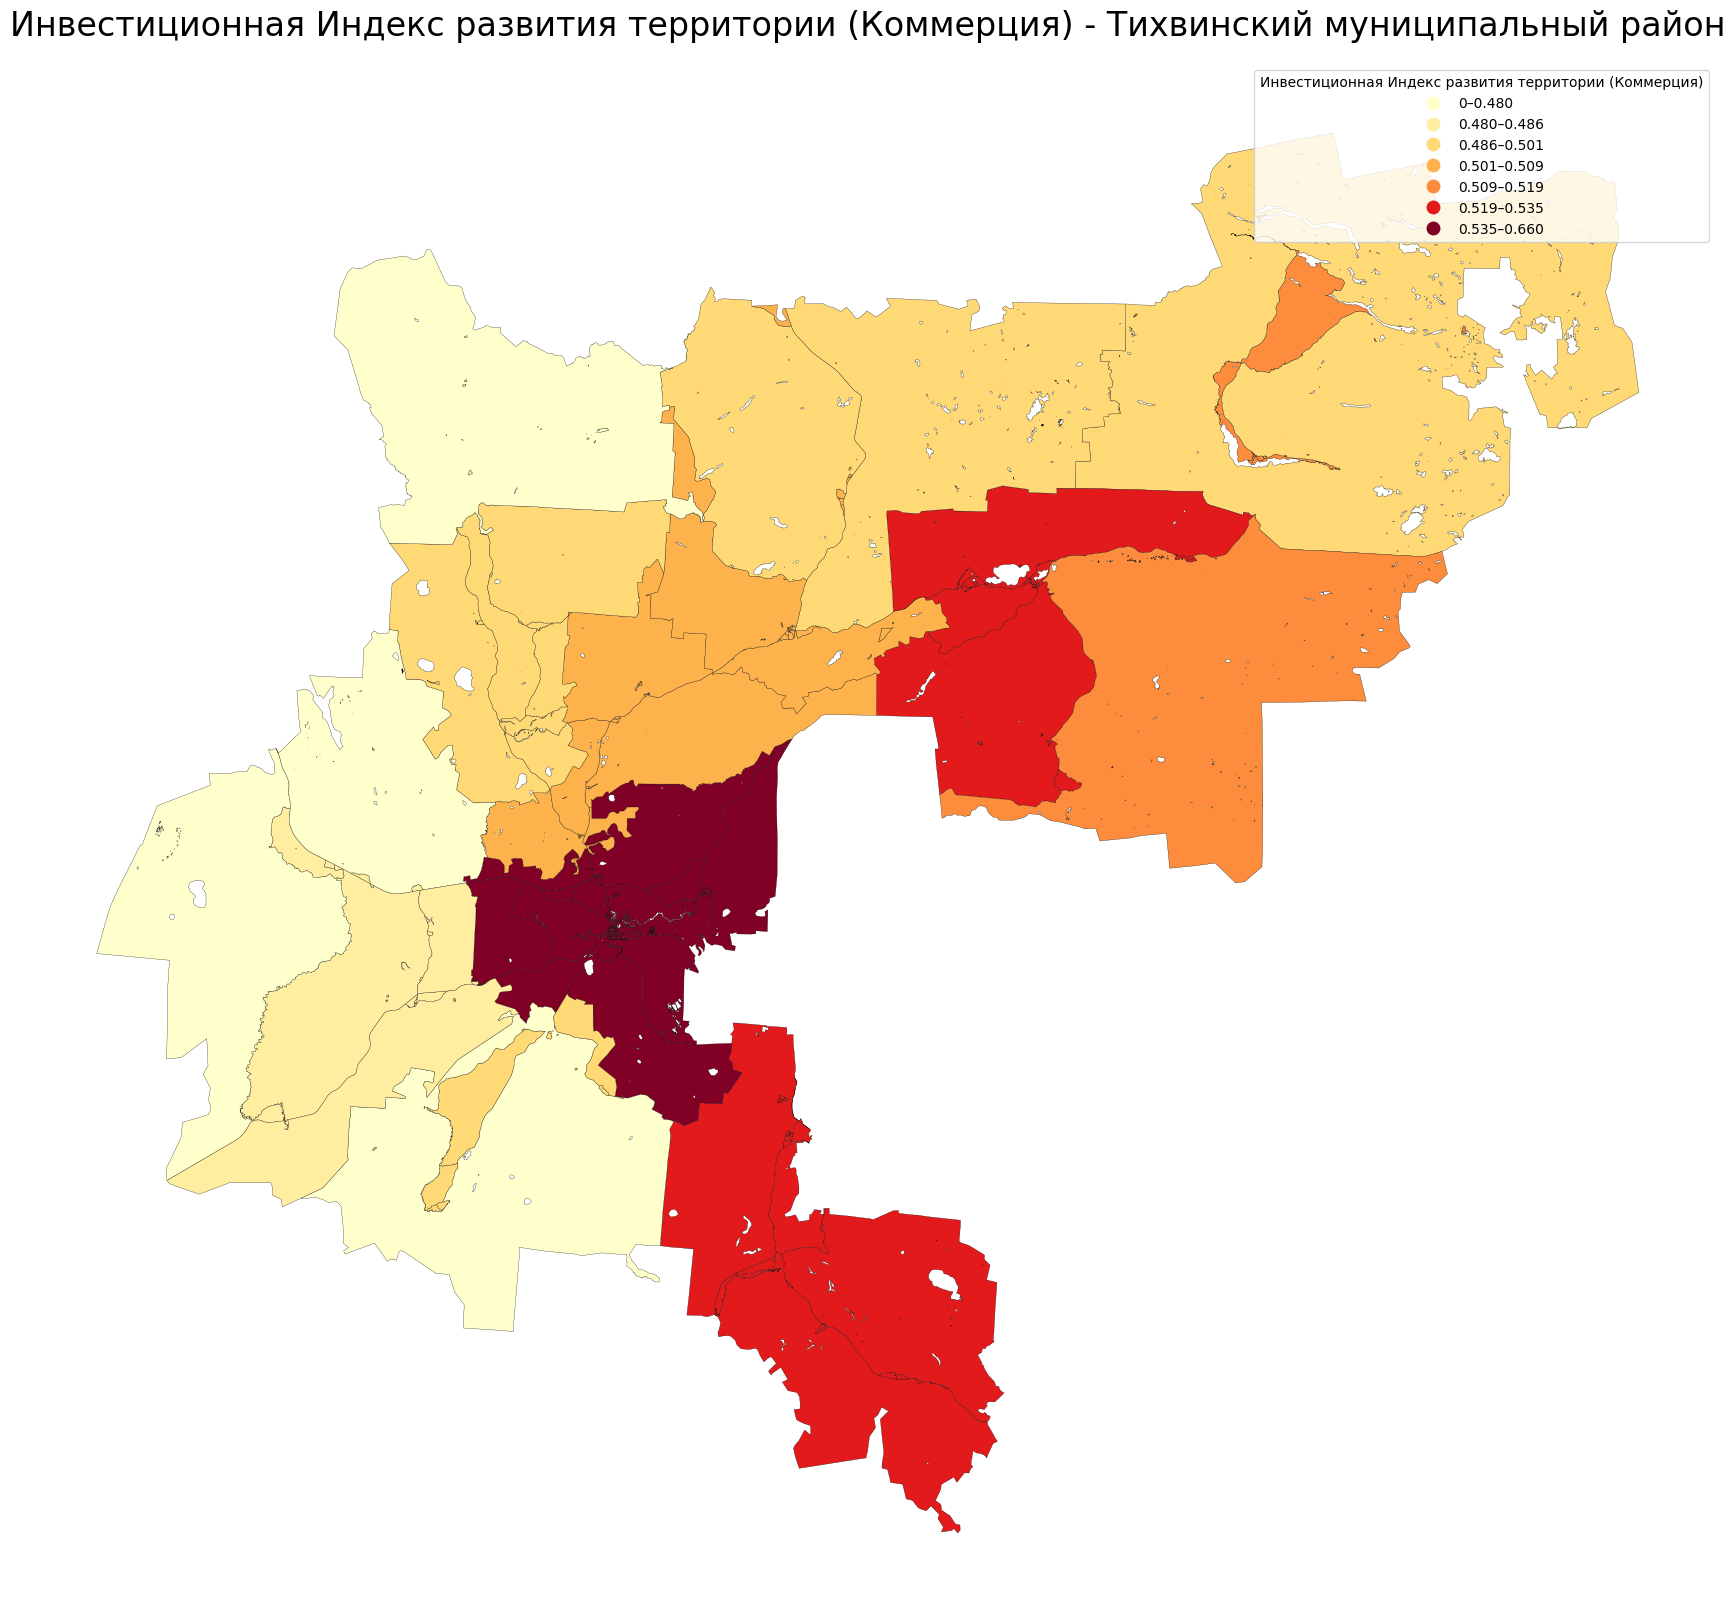

In [10]:
import matplotlib.pyplot as plt
import geopandas as gpd
import pandas as pd
import matplotlib.colors as mcolors
import mapclassify

# Фильтрация данных
filtered_gdf = gdf_grouped1[gdf_grouped1['parent_name'] == 'Тихвинский муниципальный район']
parent_name = filtered_gdf['parent_name'].iloc[0]

# Jenks Natural Breaks
classifier = mapclassify.NaturalBreaks(filtered_gdf['Invest_Commerce'], k=7)
bin_edges = classifier.bins

# Создаем метки с учетом десятичных значений
bin_labels = [f"{bin_edges[i-1]:.3f}–{b:.3f}" if i > 0 else f"0–{b:.3f}" for i, b in enumerate(bin_edges)]

# Добавляем колонку с текстовыми категориями
filtered_gdf['Категория_стоимости'] = pd.cut(
    filtered_gdf['Invest_Commerce'],
    bins=[0] + list(bin_edges),
    labels=bin_labels,
    include_lowest=True,
    ordered=False  # Указываем ordered=False, чтобы избежать ошибки с дубликатами
)

# Цвета
colors = ['#ffffcc', '#ffeda0', '#fed976', '#feb24c', '#fd8d3c', '#e31a1c', '#800026']
cmap = mcolors.ListedColormap(colors)

# Рисуем карту
fig, ax = plt.subplots(1, 1, figsize=(40, 20))

filtered_gdf.plot(
    column='Категория_стоимости',
    cmap=cmap,
    linewidth=0.2,
    edgecolor='black',
    legend=True,
    legend_kwds={'title': "Инвестиционная Индекс развития территории (Коммерция)"},
    ax=ax
)

plt.title(f'Инвестиционная Индекс развития территории (Коммерция) - {parent_name}', fontsize=24, pad=20)
plt.axis('off')
plt.show()

/home/mvin/Urbanomy/.venv/lib/python3.10/site-packages/geopandas/geodataframe.py:1819: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)


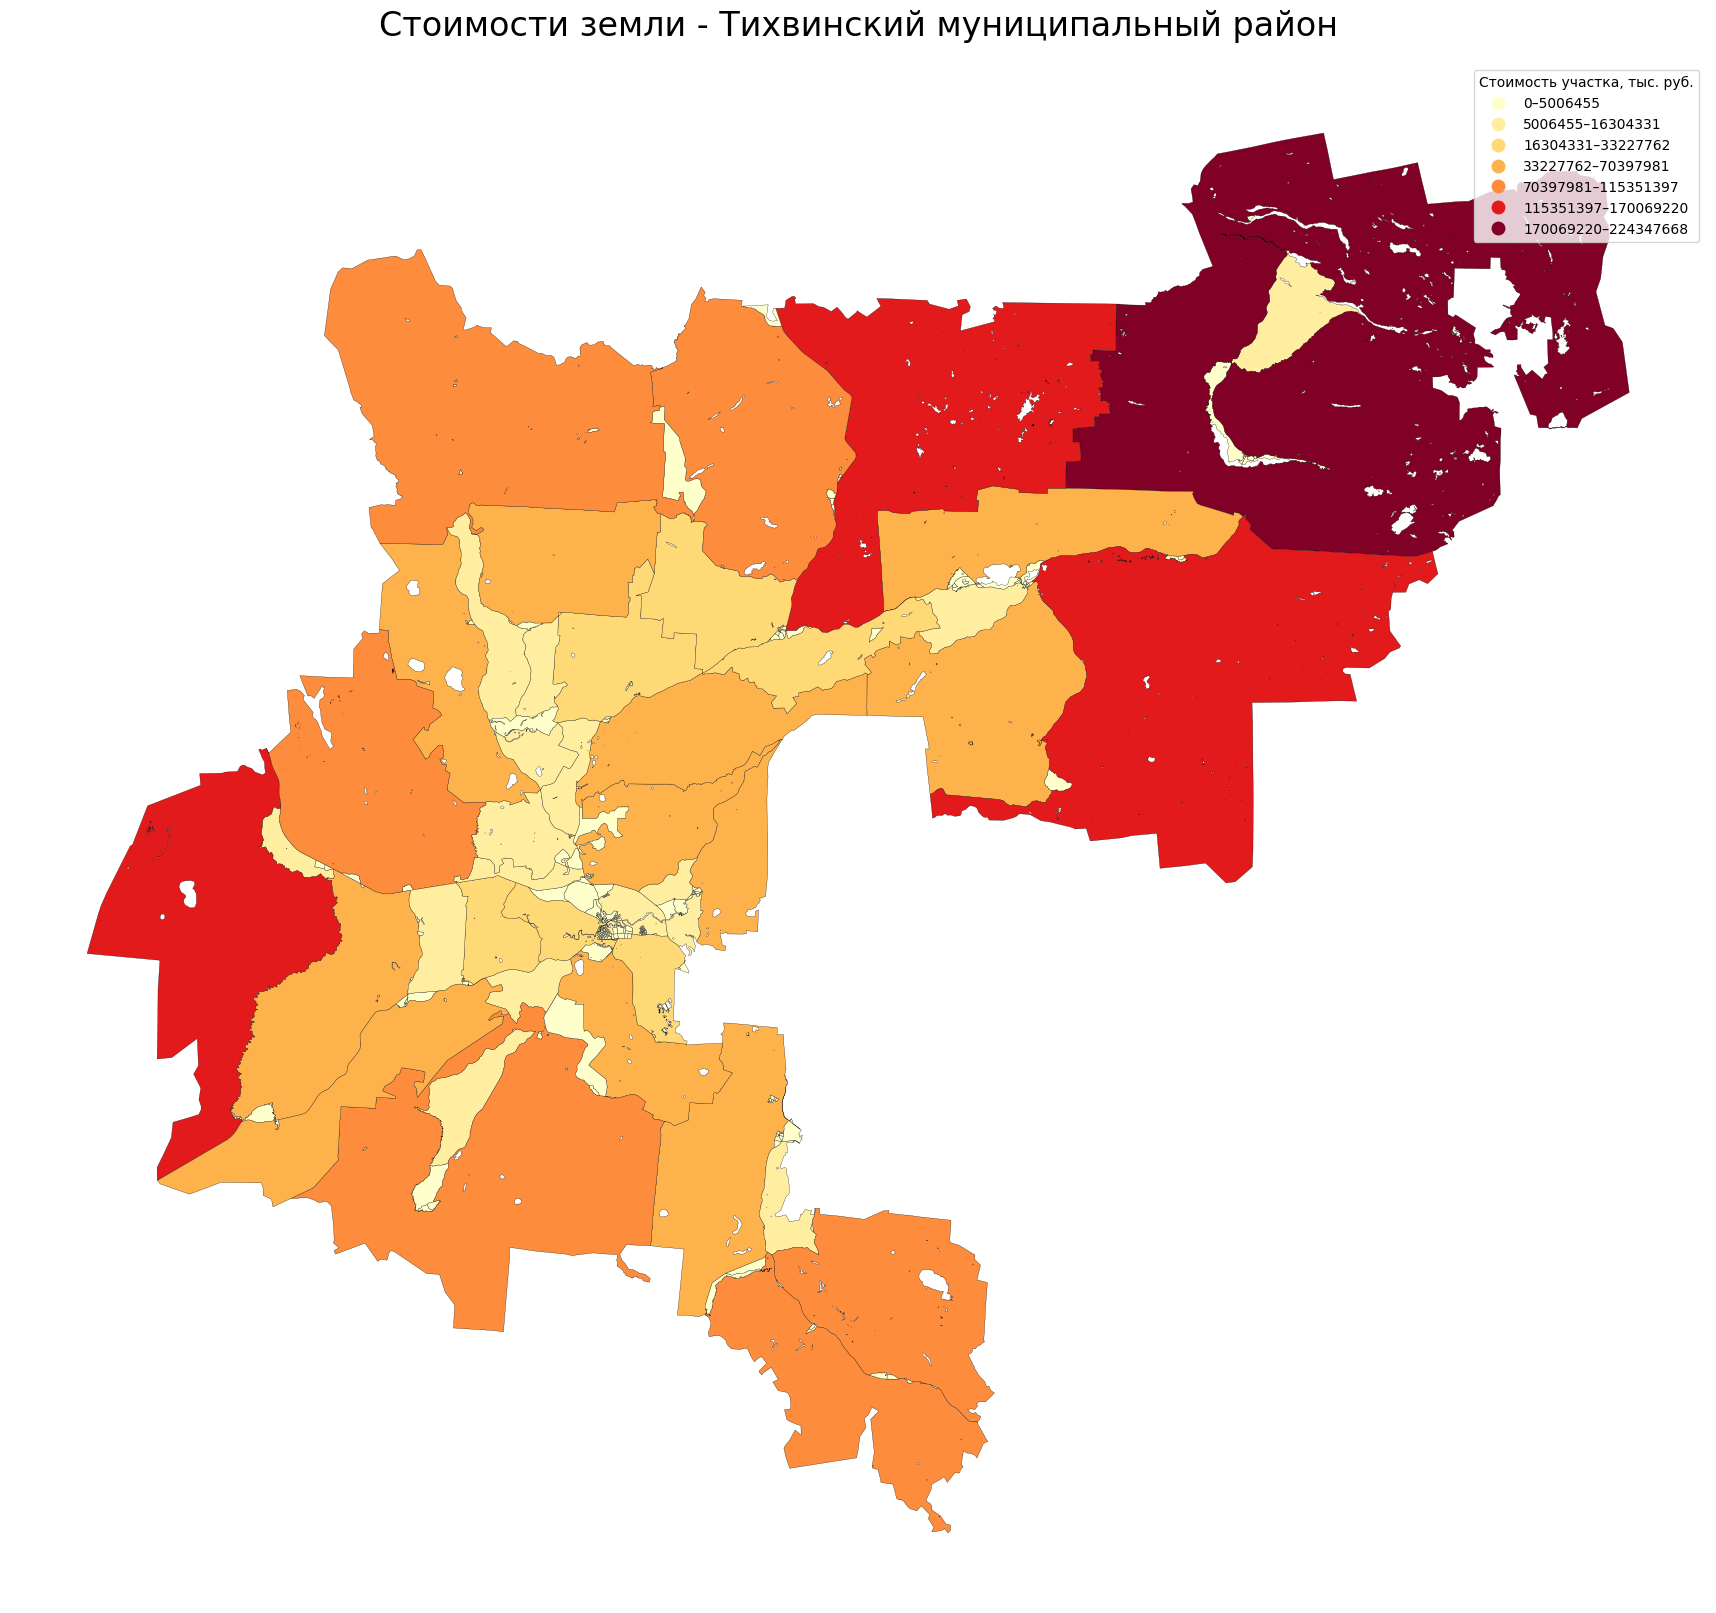

In [ ]:
# Подготовка
import matplotlib.pyplot as plt
import geopandas as gpd
import pandas as pd
import matplotlib.colors as mcolors
import mapclassify

filtered_gdf = gdf_grouped1[gdf_grouped1['parent_name'] == 'Тихвинский муниципальный район']
# filtered_gdf = gdf_grouped1[gdf_grouped1['name'] == 'город Сосновый бор']
parent_name = filtered_gdf['parent_name'].iloc[0]

# Jenks Natural Breaks
classifier = mapclassify.NaturalBreaks(filtered_gdf['Стоимость участка (тыс. руб.)'], k=7)

# Преобразуем в интервалы с подписями
bin_edges = classifier.bins
bin_labels = [f"{int(bin_edges[i-1]) if i > 0 else 0}–{int(b)}" for i, b in enumerate(bin_edges)]

# Добавляем колонку с текстовыми категориями
filtered_gdf['Категория_стоимости'] = pd.cut(
    filtered_gdf['Стоимость участка (тыс. руб.)'],
    bins=[0] + list(bin_edges),
    labels=bin_labels,
    include_lowest=True
)

# Цвета
colors = ['#ffffcc', '#ffeda0', '#fed976', '#feb24c', '#fd8d3c', '#e31a1c', '#800026']
cmap = mcolors.ListedColormap(colors)

# Рисуем карту
fig, ax = plt.subplots(1, 1, figsize=(40, 20))

filtered_gdf.plot(
    column='Категория_стоимости',
    cmap=cmap,
    linewidth=0.2,
    edgecolor='black',
    legend=True,
    legend_kwds={'title': "Стоимость участка, тыс. руб."},
    ax=ax
)

plt.title(f'Стоимости земли - {parent_name}', fontsize=24, pad=20)
plt.axis('off')
plt.show()


/home/mvin/Urbanomy/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


=== Сводная таблица метрик ===
                           CatBoost    XGBoost
Датасет          Метрика                      
Обучающие данные R2        0.951576   0.991015
                 MAPE      0.186328   0.172095
                 nRMSE     5.240015   2.257153
Тестовые данные  R2        0.740879   0.625595
                 MAPE     20.193215  18.745657
                 nRMSE     6.105196   7.338710


SHAP values (CatBoost) shape: (27952, 10)


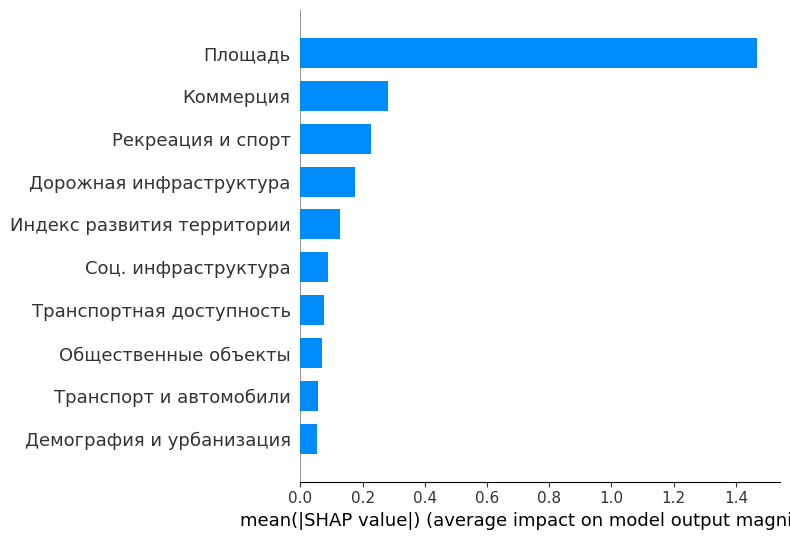

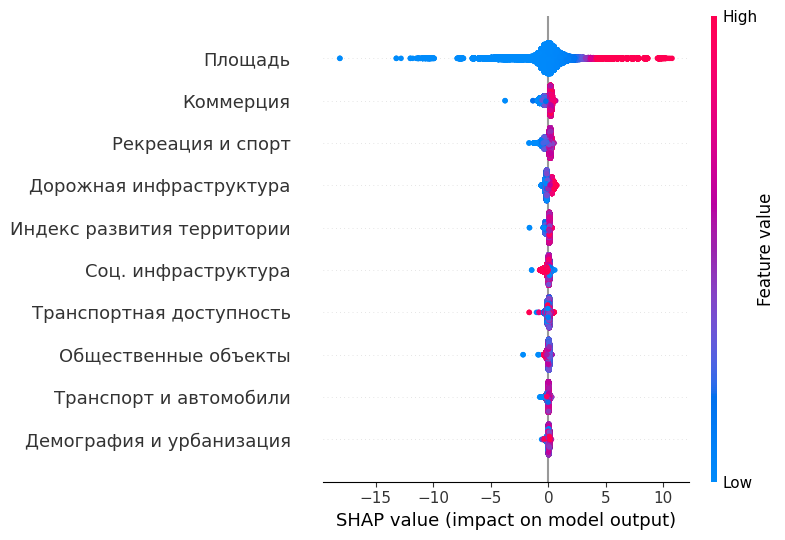

SHAP values (XGBoost) shape: (27952, 10)


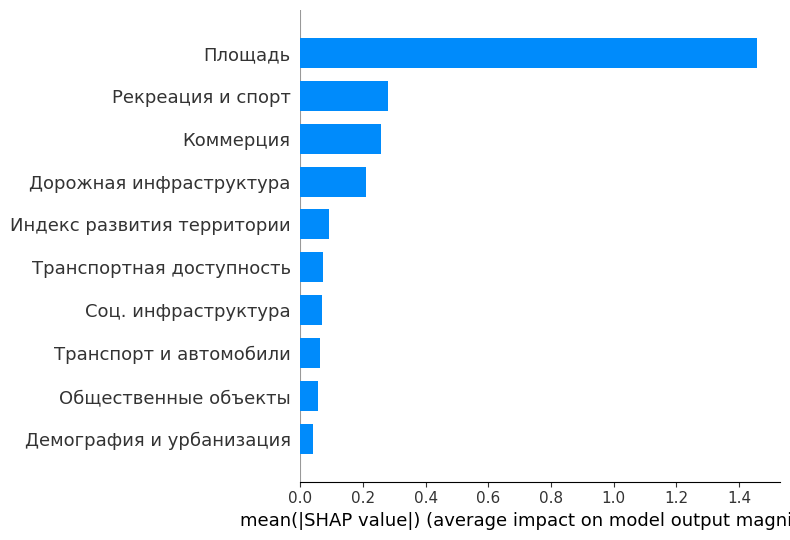

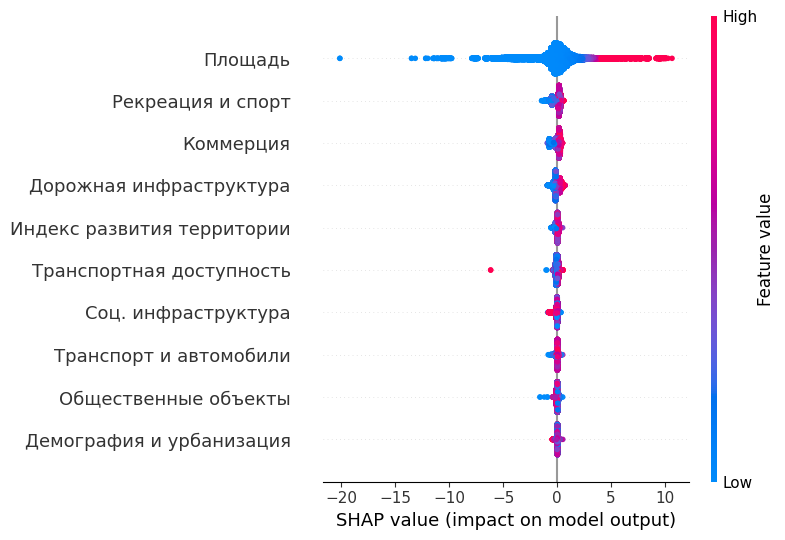

In [12]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error

from xgboost import XGBRegressor
from catboost import CatBoostRegressor

# Установите пакет shap, если не установлен:
# !pip install shap

import shap

# === 1. Функции для метрик ===
def mape(y_true, y_pred):
    """ MAPE = mean(|(y_true - y_pred) / y_true|). """
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    return np.mean(np.abs((y_true - y_pred) / y_true))

def nrmse(y_true, y_pred):
    """ nRMSE = RMSE / mean(y_true). """
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    return rmse / np.mean(y_true)


# === 2. Подготовка данных (пример) ===

# Предположим, в df у нас уже есть нужные признаки и целевая переменная
feature_cols = [
    'Демография и урбанизация',
    'Транспортная доступность',
    'Дорожная инфраструктура',
    'Транспорт и автомобили',
    'Соц. инфраструктура',
    'Коммерция',
    'Общественные объекты',
    'Рекреация и спорт',
    'Площадь',
    # 'Цена за сотку (тыс. руб.)',
    'Индекс развития территории',
]
target_col = 'Стоимость участка (тыс. руб.)'

# Предположим, в df у нас уже есть нужные признаки и целевая переменная
df_model = gdf_grouped1[feature_cols + [target_col]].dropna()

X = df_model[feature_cols]
y = df_model[target_col]


# Логарифмирование целевой (убедитесь, что у вас нет нулевых или отрицательных значений)
y_log = np.log(y)

# Разделяем на train/test
X_train, X_test, y_train_log, y_test_log = train_test_split(
    X, y_log,
    test_size=0.2,
    random_state=42
)

y_train_orig = np.exp(y_train_log)
y_test_orig  = np.exp(y_test_log)


# === 3. Обучение CatBoost ===

cat_model = CatBoostRegressor(
    iterations=500,      # Аналог n_estimators=500
    depth=6,             # Аналог max_depth=6 в XGBoost
    learning_rate=0.26,   # Аналог eta=0.3
    subsample=1.0,       # Аналог subsample=1.0 (доля объектов при бустинге)
    rsm=1.0,             # Аналог colsample_bytree=1.0 (доля признаков при сплитах)
    random_seed=42,
    verbose=False
)
cat_model.fit(X_train, y_train_log)

# Предсказания (лог-пространство)
y_train_pred_log_cat = cat_model.predict(X_train)
y_test_pred_log_cat  = cat_model.predict(X_test)

# Перевод обратно в исходную шкалу
y_train_pred_cat = np.exp(y_train_pred_log_cat)
y_test_pred_cat  = np.exp(y_test_pred_log_cat)

# Метрики CatBoost
R2_cat_train    = r2_score(y_train_orig, y_train_pred_cat)
MAPE_cat_train  = mape(y_train_orig, y_train_pred_cat)
nRMSE_cat_train = nrmse(y_train_orig, y_train_pred_cat)

R2_cat_test    = r2_score(y_test_orig, y_test_pred_cat)
MAPE_cat_test  = mape(y_test_orig, y_test_pred_cat)
nRMSE_cat_test = nrmse(y_test_orig, y_test_pred_cat)


# === 4. Обучение XGBoost ===

xgb_model = XGBRegressor(
    n_estimators=500,
    learning_rate=0.26, 
    max_depth=6,
    subsample=1.0,
    colsample_bytree=1.0,
    random_state=42
)
xgb_model.fit(X_train, y_train_log)

# Предсказания (лог-пространство)
y_train_pred_log_xgb = xgb_model.predict(X_train)
y_test_pred_log_xgb  = xgb_model.predict(X_test)

# Перевод обратно в исходную шкалу
y_train_pred_xgb = np.exp(y_train_pred_log_xgb)
y_test_pred_xgb  = np.exp(y_test_pred_log_xgb)

# Метрики XGBoost
R2_xgb_train    = r2_score(y_train_orig, y_train_pred_xgb)
MAPE_xgb_train  = mape(y_train_orig, y_train_pred_xgb)
nRMSE_xgb_train = nrmse(y_train_orig, y_train_pred_xgb)

R2_xgb_test    = r2_score(y_test_orig, y_test_pred_xgb)
MAPE_xgb_test  = mape(y_test_orig, y_test_pred_xgb)
nRMSE_xgb_test = nrmse(y_test_orig, y_test_pred_xgb)


# === 5. Сводная таблица метрик ===

metrics_data = {
    "CatBoost": [
        R2_cat_train, MAPE_cat_train, nRMSE_cat_train,
        R2_cat_test,  MAPE_cat_test,  nRMSE_cat_test
    ],
    "XGBoost": [
        R2_xgb_train, MAPE_xgb_train, nRMSE_xgb_train,
        R2_xgb_test,  MAPE_xgb_test,  nRMSE_xgb_test
    ],
}

index = pd.MultiIndex.from_tuples([
    ('Обучающие данные', 'R2'),
    ('Обучающие данные', 'MAPE'),
    ('Обучающие данные', 'nRMSE'),
    ('Тестовые данные',  'R2'),
    ('Тестовые данные',  'MAPE'),
    ('Тестовые данные',  'nRMSE'),
], names=['Датасет','Метрика'])

df_results = pd.DataFrame(metrics_data, index=index)
print("=== Сводная таблица метрик ===")
print(df_results)


# === 6. SHAP-анализ ===
# Важно: при логарифмировании целевой функции SHAP-значения будут в "лог-шкале" предсказаний.

shap.initjs()

# --- 6.1 SHAP для CatBoost ---

explainer_cat = shap.TreeExplainer(cat_model)
shap_values_cat = explainer_cat.shap_values(X_train)

print("SHAP values (CatBoost) shape:", np.array(shap_values_cat).shape)
# Обычно это (n_observations, n_features)

# Summary plot для CatBoost
shap.summary_plot(shap_values_cat, X_train, plot_type="bar")
shap.summary_plot(shap_values_cat, X_train)

# --- 6.2 SHAP для XGBoost ---
explainer_xgb = shap.TreeExplainer(xgb_model)
shap_values_xgb = explainer_xgb.shap_values(X_train)

print("SHAP values (XGBoost) shape:", np.array(shap_values_xgb).shape)

# Summary plot для XGBoost
shap.summary_plot(shap_values_xgb, X_train, plot_type="bar")
shap.summary_plot(shap_values_xgb, X_train)



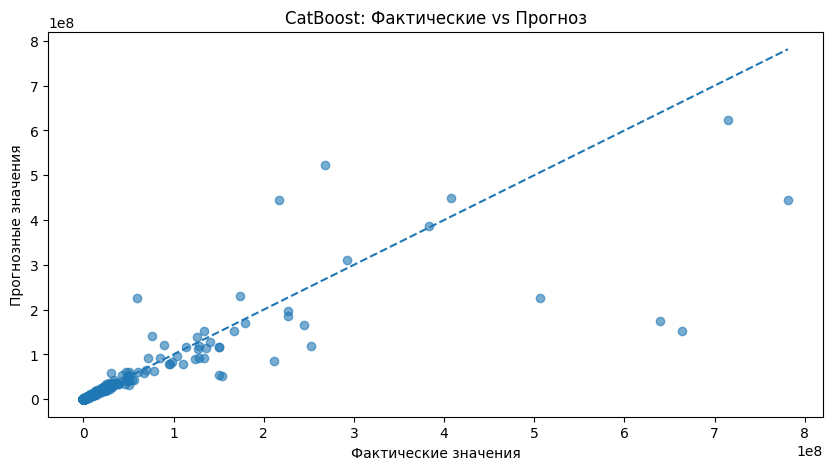

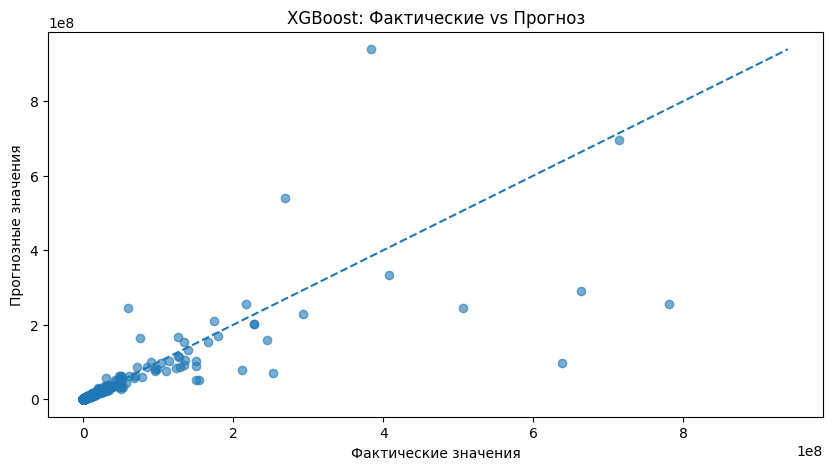

In [13]:
import matplotlib.pyplot as plt
import numpy as np

# Пример данных (предположим, что они у вас уже получены)
# y_test_orig = ...
# y_test_pred_cat = ...
# y_test_pred_xgb = ...

# Для наглядности используем min/max по фактическим и предсказанным значениям
min_val_cat = min(np.min(y_test_orig), np.min(y_test_pred_cat))
max_val_cat = max(np.max(y_test_orig), np.max(y_test_pred_cat))

min_val_xgb = min(np.min(y_test_orig), np.min(y_test_pred_xgb))
max_val_xgb = max(np.max(y_test_orig), np.max(y_test_pred_xgb))

# --- 1. Точечная диаграмма для CatBoost ---
plt.figure(figsize=(10, 5))
plt.scatter(y_test_orig, y_test_pred_cat, alpha=0.6)
plt.plot([min_val_cat, max_val_cat], [min_val_cat, max_val_cat], '--')  # линия Y=X
plt.title("CatBoost: Фактические vs Прогноз")
plt.xlabel("Фактические значения")
plt.ylabel("Прогнозные значения")
plt.show()

# --- 2. Точечная диаграмма для XGBoost ---
plt.figure(figsize=(10, 5))
plt.scatter(y_test_orig, y_test_pred_xgb, alpha=0.6)
plt.plot([min_val_xgb, max_val_xgb], [min_val_xgb, max_val_xgb], '--')  # линия Y=X
plt.title("XGBoost: Фактические vs Прогноз")
plt.xlabel("Фактические значения")
plt.ylabel("Прогнозные значения")
plt.show()


## Версия 2

In [14]:
from sklearn.preprocessing import MinMaxScaler
import pandas as pd

# Отбор колонок, где менее половины значений равны нулю
threshold_columns = [
    col for col in gdf.columns
    if (gdf[col] == 0).sum() < len(gdf) / 2 and col not in ['geometry', 'id', 'territory_id', 'name']
]

# Копируем данные без geometry
df = gdf.drop(columns=['geometry']).copy()

# Нормализуем только threshold_columns
scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(df[threshold_columns].fillna(0))

# Создаем итоговый DataFrame с нормализованными показателями
indicator_df = pd.DataFrame(scaled_data, columns=threshold_columns)
indicator_df['id'] = df['id']

# Добавляем идентификаторы и геометрию
id_columns = ['id', 'territory_id', 'name', 'geometry']
identifiers = gdf[id_columns].copy()

# Объединяем нормализованные признаки с идентификаторами
gdf_threshold = identifiers.merge(indicator_df, on='id')
gdf_threshold["Площадь"] = gdf_threshold.geometry.area

# gdf_threshold теперь содержит нормализованные threshold_columns и метаинформацию
gdf_threshold.head(5)


,id,territory_id,name,geometry,Численность населения,Степень урбанизации территории,Средняя доступность до федеральных транспортных магистралей,Средняя доступность до центра региона,Связанность,Связанность населенных пунктов,...,Обеспеченность остановками ОТ,Обеспеченность парковками,Обеспеченность автозаправками,Обеспеченность ЖД станциями,Обеспеченность автосалонами / автосервисами,Обеспеченность участковыми пунктами полиции,Обеспеченность опорными пунктами полиции,Обеспеченность пожарными депо,Связанность общественным транспортом,Площадь
0,0,3.0,Самойловское сельское поселение,"POLYGON ((570883.045 6596529.946, 570883.081 6...",0.01619,0.243146,3.386562e-305,0.781437,0.789257,2.664748e-306,...,0.88,0.06,0.86,0.08,0.0,0.12,1.0,0.0,2.664748e-306,1.373078e+06
1,1,3.0,Самойловское сельское поселение,"POLYGON ((570987.035 6596464.499, 570987.085 6...",0.01619,0.243146,3.386562e-305,0.781437,0.789257,2.664748e-306,...,0.88,0.06,0.86,0.08,0.0,0.12,1.0,0.0,2.664748e-306,7.709275e+02
2,2,3.0,Самойловское сельское поселение,"POLYGON ((572676.73 6596606.982, 572676.701 65...",0.01619,0.243146,3.386562e-305,0.781437,0.789257,2.664748e-306,...,0.88,0.06,0.86,0.08,0.0,0.12,1.0,0.0,2.664748e-306,6.040730e+02
3,3,3.0,Самойловское сельское поселение,"POLYGON ((583242.895 6595451.954, 583243.013 6...",0.01619,0.243146,3.386562e-305,0.781437,0.789257,2.664748e-306,...,0.88,0.06,0.86,0.08,0.0,0.12,1.0,0.0,2.664748e-306,4.519286e+04
4,4,3.0,Самойловское сельское поселение,"POLYGON ((582405.498 6595459.455, 582405.614 6...",0.01619,0.243146,3.386562e-305,0.781437,0.789257,2.664748e-306,...,0.88,0.06,0.86,0.08,0.0,0.12,1.0,0.0,2.664748e-306,1.982999e+02


In [15]:
# import numpy as np
# import pandas as pd
# from scipy.stats import skew, kurtosis

# # Исключаем идентификационные и геометрические колонки
# exclude_cols = ['id', 'territory_id', 'name', 'geometry']

# # Оставляем только нормализованные признаки
# threshold_stats_df = gdf_threshold.drop(columns=exclude_cols + ['Площадь']).copy()

# # Функция для расширенной статистики
# def extended_stats(df):
#     stats = df.describe().T
#     stats['median'] = df.median()
#     stats['range'] = df.max() - df.min()
#     stats['skewness'] = df.skew()
#     stats['kurtosis'] = df.kurtosis()
#     stats['missing_%'] = df.isna().mean() * 100
#     return stats

# # Получаем статистики
# threshold_column_stats = extended_stats(threshold_stats_df)

# print("\n📊 Статистика по threshold-признакам:")
# display(threshold_column_stats)


In [16]:
territory_gdf = gpd.read_file('data/level_4_territories.geojson').to_crs(32636)
import json

# Убедимся, что parent — это словарь (если он закодирован как строка — преобразуем)
def extract_parent_name(x):
    if isinstance(x, str):
        try:
            x = json.loads(x)
        except json.JSONDecodeError:
            return None
    if isinstance(x, dict):
        return x.get("name")
    return None

# Создаём вспомогательный DataFrame
parent_df = territory_gdf[['name', 'parent']].copy()
parent_df['parent_name'] = parent_df['parent'].apply(extract_parent_name)

# Оставим только нужные колонки
parent_df = parent_df[['name', 'parent_name']]

# Мёржим с gdf_grouped
gdf_threshold = gdf_threshold.merge(parent_df, on='name', how='left')
gdf_threshold.head(5)

,id,territory_id,name,geometry,Численность населения,Степень урбанизации территории,Средняя доступность до федеральных транспортных магистралей,Средняя доступность до центра региона,Связанность,Связанность населенных пунктов,...,Обеспеченность парковками,Обеспеченность автозаправками,Обеспеченность ЖД станциями,Обеспеченность автосалонами / автосервисами,Обеспеченность участковыми пунктами полиции,Обеспеченность опорными пунктами полиции,Обеспеченность пожарными депо,Связанность общественным транспортом,Площадь,parent_name
0,0,3.0,Самойловское сельское поселение,"POLYGON ((570883.045 6596529.946, 570883.081 6...",0.01619,0.243146,3.386562e-305,0.781437,0.789257,2.664748e-306,...,0.06,0.86,0.08,0.0,0.12,1.0,0.0,2.664748e-306,1.373078e+06,Бокситогорский муниципальный район
1,1,3.0,Самойловское сельское поселение,"POLYGON ((570987.035 6596464.499, 570987.085 6...",0.01619,0.243146,3.386562e-305,0.781437,0.789257,2.664748e-306,...,0.06,0.86,0.08,0.0,0.12,1.0,0.0,2.664748e-306,7.709275e+02,Бокситогорский муниципальный район
2,2,3.0,Самойловское сельское поселение,"POLYGON ((572676.73 6596606.982, 572676.701 65...",0.01619,0.243146,3.386562e-305,0.781437,0.789257,2.664748e-306,...,0.06,0.86,0.08,0.0,0.12,1.0,0.0,2.664748e-306,6.040730e+02,Бокситогорский муниципальный район
3,3,3.0,Самойловское сельское поселение,"POLYGON ((583242.895 6595451.954, 583243.013 6...",0.01619,0.243146,3.386562e-305,0.781437,0.789257,2.664748e-306,...,0.06,0.86,0.08,0.0,0.12,1.0,0.0,2.664748e-306,4.519286e+04,Бокситогорский муниципальный район
4,4,3.0,Самойловское сельское поселение,"POLYGON ((582405.498 6595459.455, 582405.614 6...",0.01619,0.243146,3.386562e-305,0.781437,0.789257,2.664748e-306,...,0.06,0.86,0.08,0.0,0.12,1.0,0.0,2.664748e-306,1.982999e+02,Бокситогорский муниципальный район


In [ ]:
# Шаг 1 — копируем оригинальный GeoDataFrame с нормализованными признаками
gdf_grouped1 = gdf_threshold.copy()

# Шаг 2 — определим список нормализованных колонок (исключая идентификаторы и служебные поля)
exclude_cols = ['id', 'territory_id', 'name', 'geometry', 'Площадь', 'parent_name']
indicator_columns = [col for col in gdf_grouped1.columns if col not in exclude_cols]

# Шаг 3 — расчёт "коэффициента привлекательности" как среднего по нормализованным колонкам
gdf_grouped1["Индекс развития территории"] = gdf_grouped1[indicator_columns].mean(axis=1)

# # Шаг 4 — сглаживание (минимум 0.5)
# gdf_grouped1["Индекс развития территории_сглаженая"] = gdf_grouped1["Индекс развития территории"].apply(lambda x: max(0.5, x))

# Шаг 5 — пересчёт площади в сотки (100 м² = 1 сотка)
gdf_grouped1["Площадь (сотки)"] = gdf_grouped1["Площадь"] / 100

# Шаг 6 — словарь цен за сотку по районам
districts_dict = {
    "Бокситогорский муниципальный район": 70,
    "Волосовский муниципальный район": 78,
    "Волховский муниципальный район": 101,
    "Всеволожский муниципальный район": 552,
    "Выборгский муниципальный район": 434,
    "Гатчинский муниципальный район": 272,
    "Кингисеппский муниципальный район": 94,
    "Киришский муниципальный район": 51,
    "Кировский муниципальный район": 227,
    "Лодейнопольский муниципальный район": 59,
    "Ломоносовский муниципальный район": 334,
    "Лужский муниципальный район": 66,
    "Подпорожский муниципальный район": 88,
    "Приозерский муниципальный район": 262,
    "Сланцевский муниципальный район": 21,
    "Тихвинский муниципальный район": 110,
    "Тосненский муниципальный район": 237,
    "Сосновоборский городской округ": 100
}

# Шаг 7 — добавление цены за сотку
gdf_grouped1["Цена за сотку (тыс. руб.)"] = gdf_grouped1["parent_name"].map(districts_dict)

# Шаг 8 — расчёт итоговой стоимости участка (в тыс. рублей)
gdf_grouped1["Стоимость участка (тыс. руб.)"] = (
    gdf_grouped1["Площадь (сотки)"] *
    gdf_grouped1["Цена за сотку (тыс. руб.)"] *
    gdf_grouped1["Индекс развития территории"]
)

# Готово — можно смотреть результат
gdf_grouped1.head()


,id,territory_id,name,geometry,Численность населения,Степень урбанизации территории,Средняя доступность до федеральных транспортных магистралей,Средняя доступность до центра региона,Связанность,Связанность населенных пунктов,...,Обеспеченность участковыми пунктами полиции,Обеспеченность опорными пунктами полиции,Обеспеченность пожарными депо,Связанность общественным транспортом,Площадь,parent_name,Индекс развития территории,Площадь (сотки),Цена за сотку (тыс. руб.),Стоимость_участка_тыс_руб
0,0,3.0,Самойловское сельское поселение,"POLYGON ((570883.045 6596529.946, 570883.081 6...",0.01619,0.243146,3.386562e-305,0.781437,0.789257,2.664748e-306,...,0.12,1.0,0.0,2.664748e-306,1.373078e+06,Бокситогорский муниципальный район,0.311962,13730.782419,70,299844.048521
1,1,3.0,Самойловское сельское поселение,"POLYGON ((570987.035 6596464.499, 570987.085 6...",0.01619,0.243146,3.386562e-305,0.781437,0.789257,2.664748e-306,...,0.12,1.0,0.0,2.664748e-306,7.709275e+02,Бокситогорский муниципальный район,0.311962,7.709275,70,168.350225
2,2,3.0,Самойловское сельское поселение,"POLYGON ((572676.73 6596606.982, 572676.701 65...",0.01619,0.243146,3.386562e-305,0.781437,0.789257,2.664748e-306,...,0.12,1.0,0.0,2.664748e-306,6.040730e+02,Бокситогорский муниципальный район,0.311962,6.040730,70,131.913609
3,3,3.0,Самойловское сельское поселение,"POLYGON ((583242.895 6595451.954, 583243.013 6...",0.01619,0.243146,3.386562e-305,0.781437,0.789257,2.664748e-306,...,0.12,1.0,0.0,2.664748e-306,4.519286e+04,Бокситогорский муниципальный район,0.311962,451.928570,70,9868.927193
4,4,3.0,Самойловское сельское поселение,"POLYGON ((582405.498 6595459.455, 582405.614 6...",0.01619,0.243146,3.386562e-305,0.781437,0.789257,2.664748e-306,...,0.12,1.0,0.0,2.664748e-306,1.982999e+02,Бокситогорский муниципальный район,0.311962,1.982999,70,43.303465


/home/mvin/Urbanomy/.venv/lib/python3.10/site-packages/geopandas/geodataframe.py:1819: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)


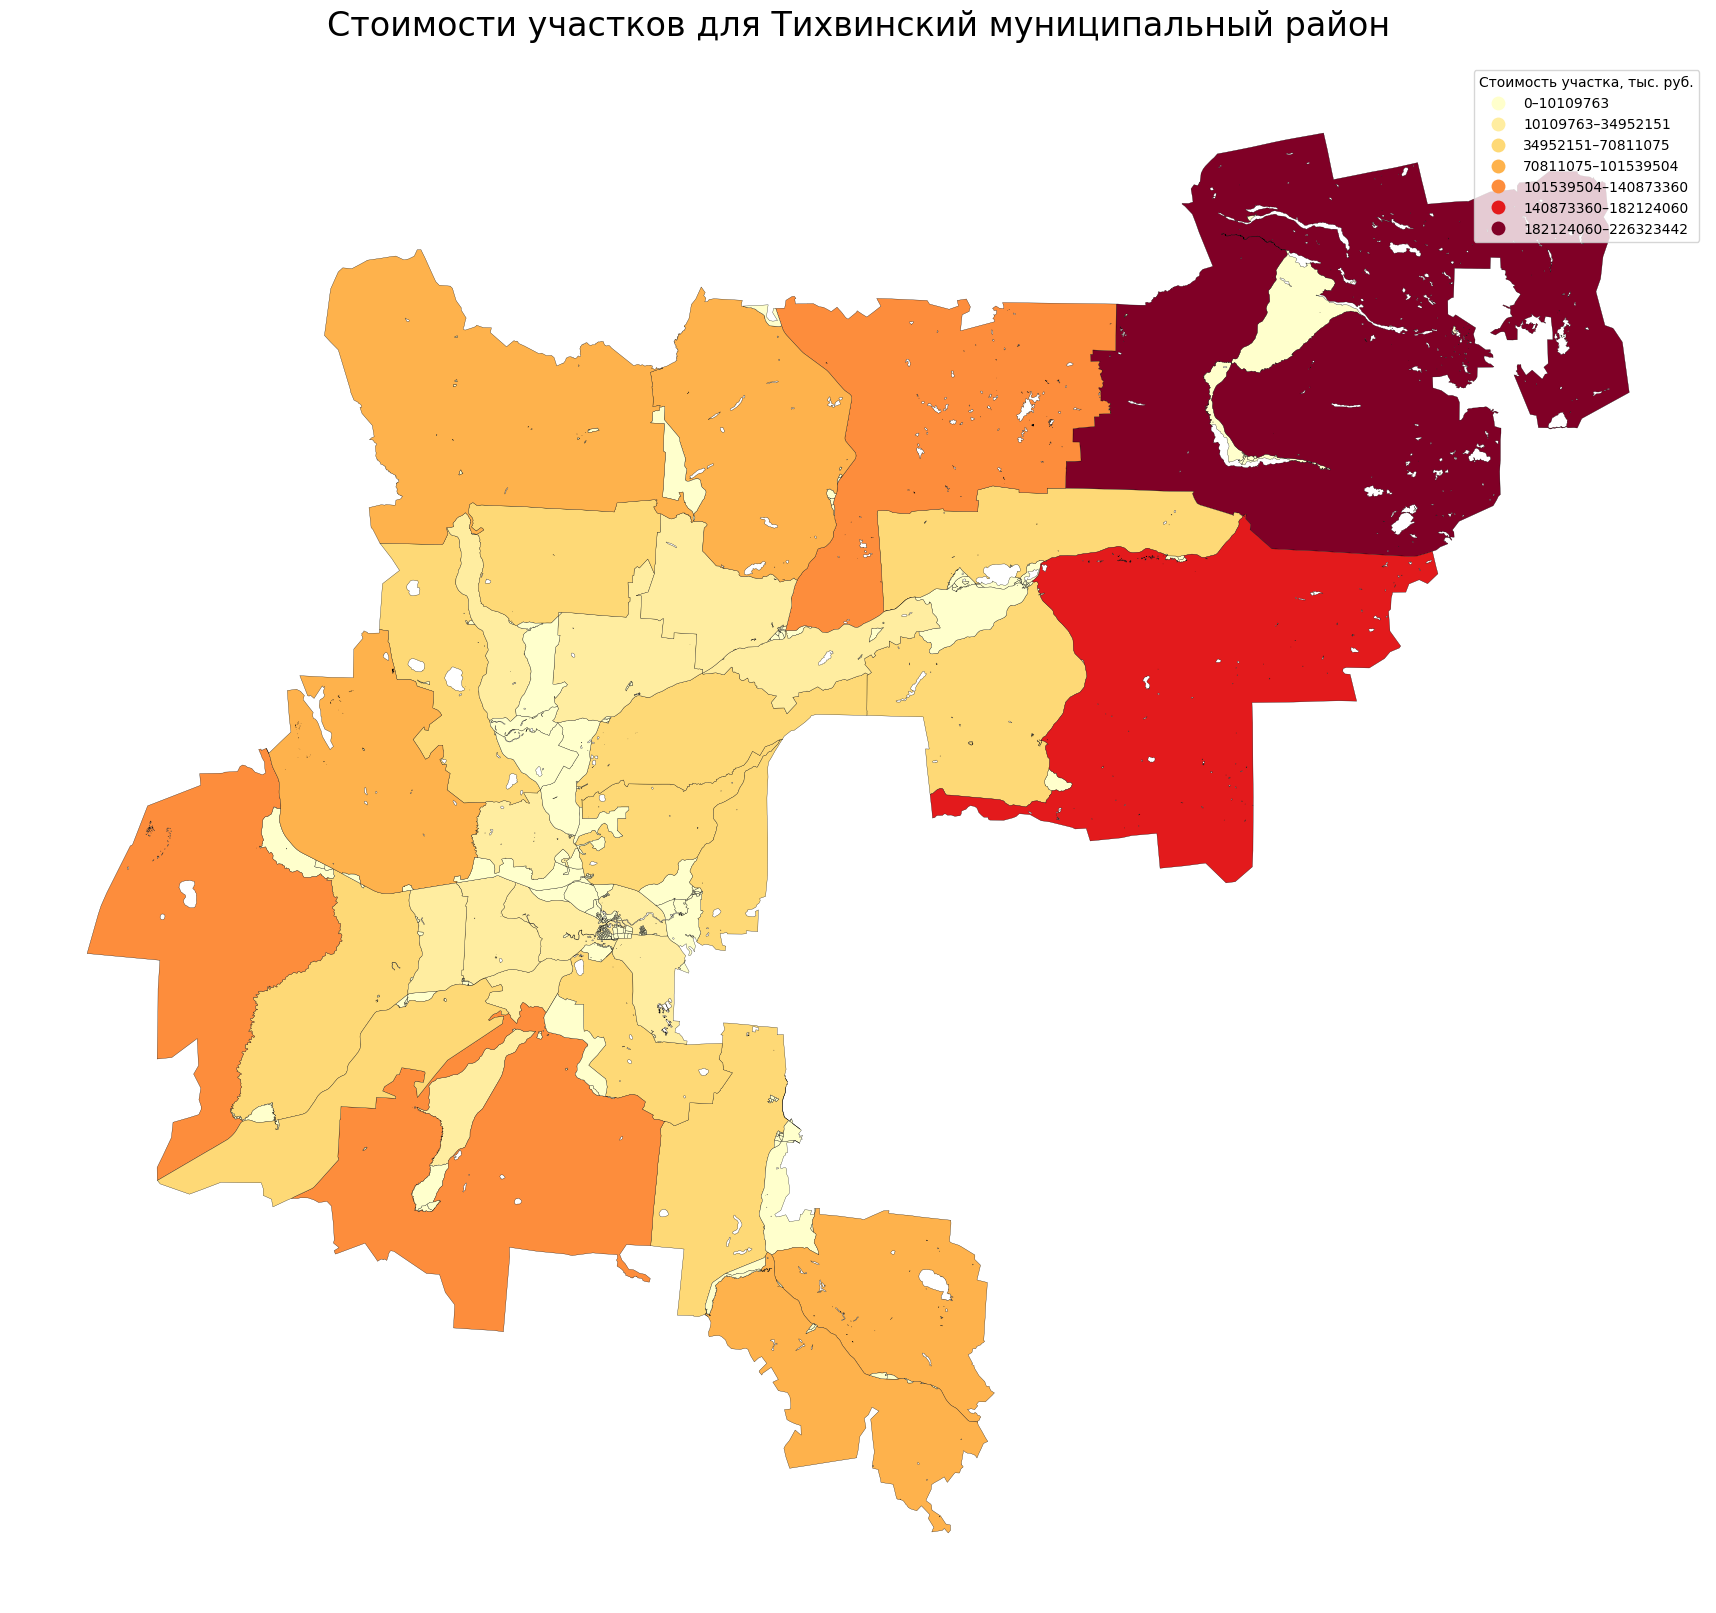

In [ ]:
# Подготовка
import matplotlib.pyplot as plt
import geopandas as gpd
import pandas as pd
import matplotlib.colors as mcolors
import mapclassify

filtered_gdf = gdf_grouped1[gdf_grouped1['parent_name'] == 'Тихвинский муниципальный район']
parent_name = filtered_gdf['parent_name'].iloc[0]

# Jenks Natural Breaks
classifier = mapclassify.NaturalBreaks(filtered_gdf['Стоимость участка (тыс. руб.)'], k=7)

# Преобразуем в интервалы с подписями
bin_edges = classifier.bins
bin_labels = [f"{int(bin_edges[i-1]) if i > 0 else 0}–{int(b)}" for i, b in enumerate(bin_edges)]

# Добавляем колонку с текстовыми категориями
filtered_gdf['Категория_стоимости'] = pd.cut(
    filtered_gdf['Стоимость участка (тыс. руб.)'],
    bins=[0] + list(bin_edges),
    labels=bin_labels,
    include_lowest=True
)

# Цвета
colors = ['#ffffcc', '#ffeda0', '#fed976', '#feb24c', '#fd8d3c', '#e31a1c', '#800026']
cmap = mcolors.ListedColormap(colors)

# Рисуем карту
fig, ax = plt.subplots(1, 1, figsize=(40, 20))

filtered_gdf.plot(
    column='Категория_стоимости',
    cmap=cmap,
    linewidth=0.2,
    edgecolor='black',
    legend=True,
    legend_kwds={'title': "Стоимость участка, тыс. руб."},
    ax=ax
)

plt.title(f'Стоимости участков для {parent_name}', fontsize=24, pad=20)
plt.axis('off')
plt.show()



=== Сводная таблица метрик ===
                           CatBoost    XGBoost
Датасет          Метрика                      
Обучающие данные R2        0.987992   0.991943
                 MAPE      0.180922   0.170124
                 nRMSE     2.617421   2.144051
Тестовые данные  R2        0.774092   0.638825
                 MAPE     19.678279  18.753551
                 nRMSE     5.657407   7.153363


SHAP values (CatBoost) shape: (27952, 54)


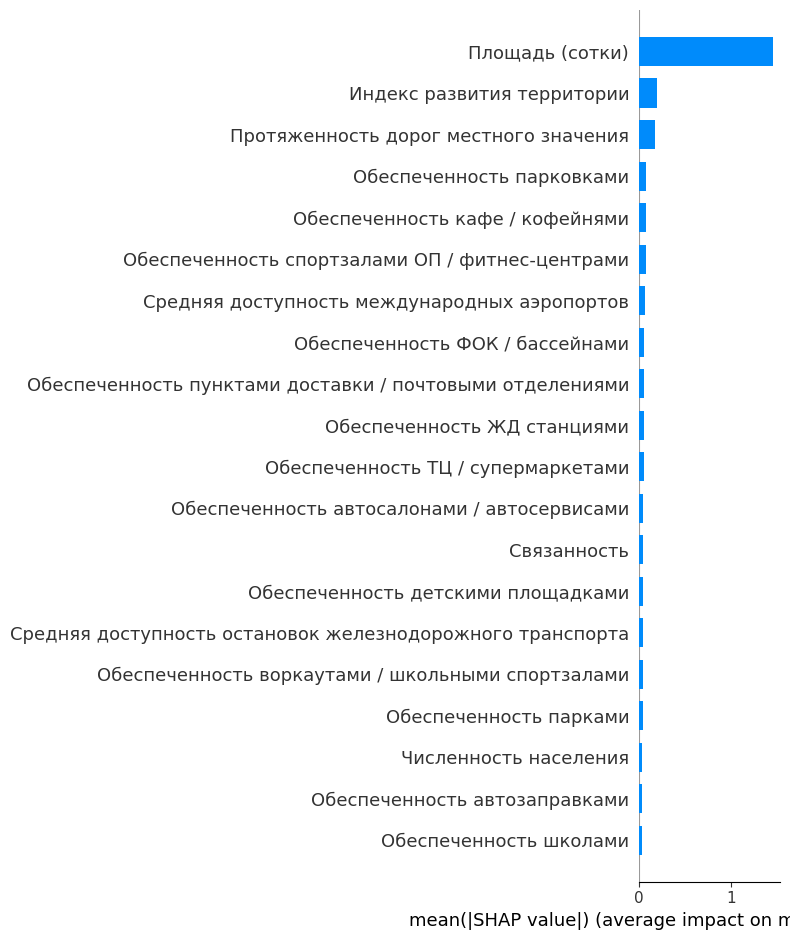

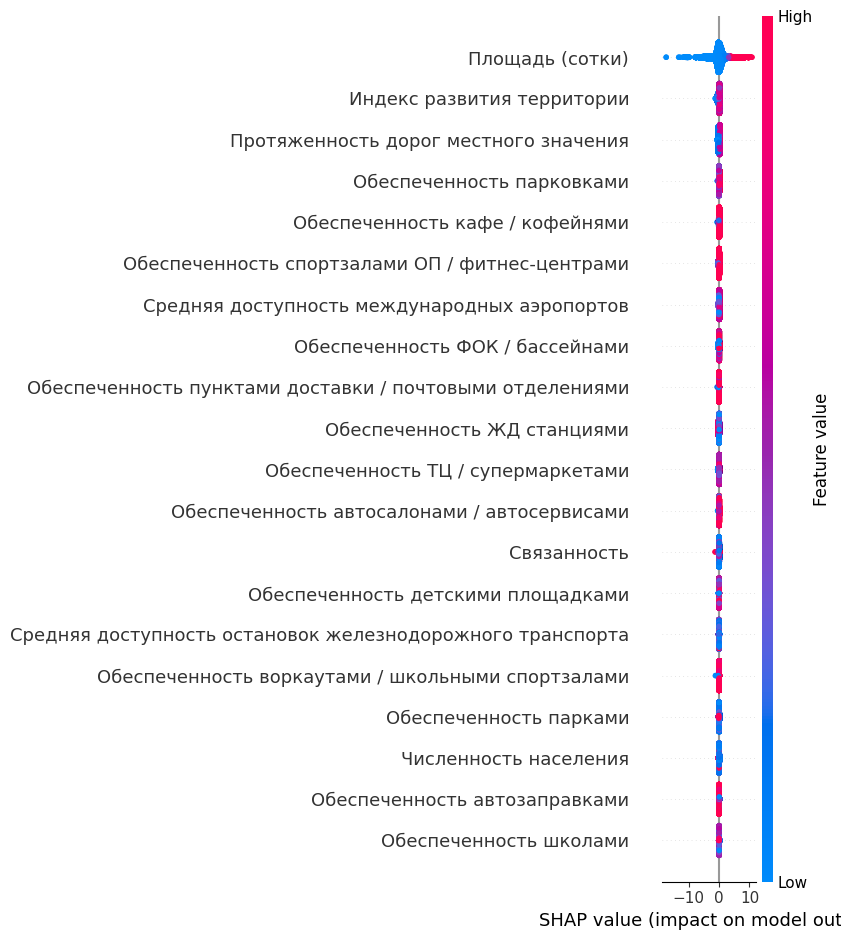

SHAP values (XGBoost) shape: (27952, 54)


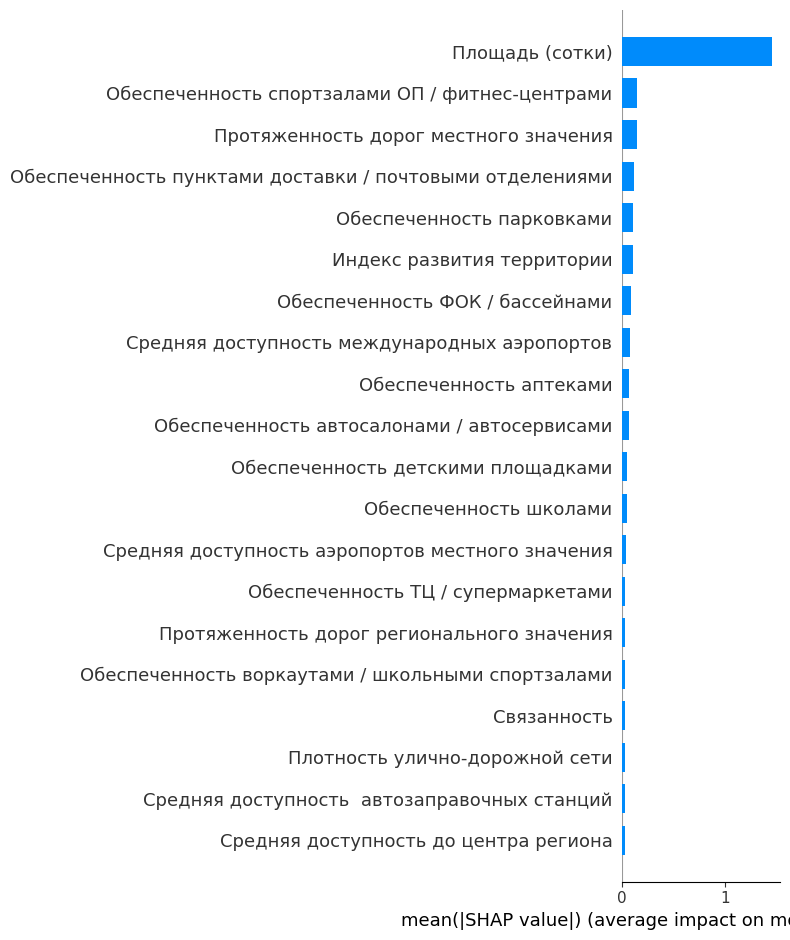

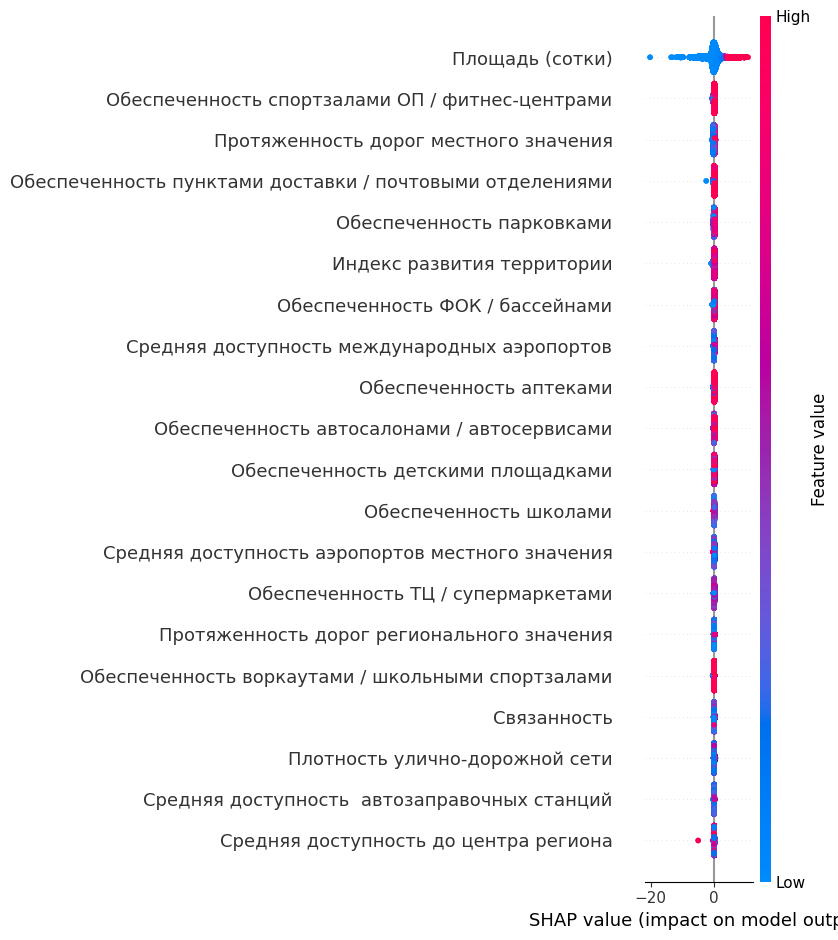

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error

from xgboost import XGBRegressor
from catboost import CatBoostRegressor

# Установите пакет shap, если не установлен:
# !pip install shap

import shap

# === 1. Функции для метрик ===
def mape(y_true, y_pred):
    """ MAPE = mean(|(y_true - y_pred) / y_true|). """
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    return np.mean(np.abs((y_true - y_pred) / y_true))

def nrmse(y_true, y_pred):
    """ nRMSE = RMSE / mean(y_true). """
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    return rmse / np.mean(y_true)


# === 2. Подготовка данных (обновлённая версия) ===

# Список базовых признаков: нормализованные threshold-признаки
exclude_cols = ['id', 'territory_id', 'name', 'geometry', 'Площадь', 'parent_name',
                'Площадь (сотки)', 'Цена за сотку (тыс. руб.)', 'Индекс развития территории',
                'Стоимость участка (тыс. руб.)']
threshold_features = [
    col for col in gdf_grouped1.columns
    if col not in exclude_cols and pd.api.types.is_numeric_dtype(gdf_grouped1[col])
]

# Добавим дополнительные признаки
extra_features = ['Площадь (сотки)', 'Индекс развития территории']
# Финальный список признаков
feature_cols = threshold_features + extra_features
target_col = 'Стоимость участка (тыс. руб.)'

# Подготовка датасета для модели
df_model = gdf_grouped1[feature_cols + [target_col]].dropna()

X = df_model[feature_cols]
y = df_model[target_col]


# Логарифмирование целевой (убедитесь, что у вас нет нулевых или отрицательных значений)
y_log = np.log(y)

# Разделяем на train/test
X_train, X_test, y_train_log, y_test_log = train_test_split(
    X, y_log,
    test_size=0.2,
    random_state=42
)

y_train_orig = np.exp(y_train_log)
y_test_orig  = np.exp(y_test_log)


# === 3. Обучение CatBoost ===

cat_model = CatBoostRegressor(
    iterations=500,      # Аналог n_estimators=500
    depth=6,             # Аналог max_depth=6 в XGBoost
    learning_rate=0.26,   # Аналог eta=0.3
    subsample=1.0,       # Аналог subsample=1.0 (доля объектов при бустинге)
    rsm=1.0,             # Аналог colsample_bytree=1.0 (доля признаков при сплитах)
    random_seed=42,
    verbose=False
)
cat_model.fit(X_train, y_train_log)

# Предсказания (лог-пространство)
y_train_pred_log_cat = cat_model.predict(X_train)
y_test_pred_log_cat  = cat_model.predict(X_test)

# Перевод обратно в исходную шкалу
y_train_pred_cat = np.exp(y_train_pred_log_cat)
y_test_pred_cat  = np.exp(y_test_pred_log_cat)

# Метрики CatBoost
R2_cat_train    = r2_score(y_train_orig, y_train_pred_cat)
MAPE_cat_train  = mape(y_train_orig, y_train_pred_cat)
nRMSE_cat_train = nrmse(y_train_orig, y_train_pred_cat)

R2_cat_test    = r2_score(y_test_orig, y_test_pred_cat)
MAPE_cat_test  = mape(y_test_orig, y_test_pred_cat)
nRMSE_cat_test = nrmse(y_test_orig, y_test_pred_cat)


# === 4. Обучение XGBoost ===

xgb_model = XGBRegressor(
    n_estimators=500,
    learning_rate=0.26, 
    max_depth=6,
    subsample=1.0,
    colsample_bytree=1.0,
    random_state=42
)
xgb_model.fit(X_train, y_train_log)

# Предсказания (лог-пространство)
y_train_pred_log_xgb = xgb_model.predict(X_train)
y_test_pred_log_xgb  = xgb_model.predict(X_test)

# Перевод обратно в исходную шкалу
y_train_pred_xgb = np.exp(y_train_pred_log_xgb)
y_test_pred_xgb  = np.exp(y_test_pred_log_xgb)

# Метрики XGBoost
R2_xgb_train    = r2_score(y_train_orig, y_train_pred_xgb)
MAPE_xgb_train  = mape(y_train_orig, y_train_pred_xgb)
nRMSE_xgb_train = nrmse(y_train_orig, y_train_pred_xgb)

R2_xgb_test    = r2_score(y_test_orig, y_test_pred_xgb)
MAPE_xgb_test  = mape(y_test_orig, y_test_pred_xgb)
nRMSE_xgb_test = nrmse(y_test_orig, y_test_pred_xgb)


# === 5. Сводная таблица метрик ===

metrics_data = {
    "CatBoost": [
        R2_cat_train, MAPE_cat_train, nRMSE_cat_train,
        R2_cat_test,  MAPE_cat_test,  nRMSE_cat_test
    ],
    "XGBoost": [
        R2_xgb_train, MAPE_xgb_train, nRMSE_xgb_train,
        R2_xgb_test,  MAPE_xgb_test,  nRMSE_xgb_test
    ],
}

index = pd.MultiIndex.from_tuples([
    ('Обучающие данные', 'R2'),
    ('Обучающие данные', 'MAPE'),
    ('Обучающие данные', 'nRMSE'),
    ('Тестовые данные',  'R2'),
    ('Тестовые данные',  'MAPE'),
    ('Тестовые данные',  'nRMSE'),
], names=['Датасет','Метрика'])

df_results = pd.DataFrame(metrics_data, index=index)
print("=== Сводная таблица метрик ===")
print(df_results)


# === 6. SHAP-анализ ===
# Важно: при логарифмировании целевой функции SHAP-значения будут в "лог-шкале" предсказаний.

shap.initjs()

# --- 6.1 SHAP для CatBoost ---
# Используем встроенный в CatBoost метод получения SHAP, либо библиотеку shap.

# Вариант 1: через встроенный метод CatBoost
#    cat_shap_values = cat_model.get_feature_importance(
#        type="ShapValues", 
#        data=Pool(X_train, label=y_train_log)
#    )
# Однако чаще используется сам shap.TreeExplainer (ниже).

explainer_cat = shap.TreeExplainer(cat_model)
shap_values_cat = explainer_cat.shap_values(X_train)

print("SHAP values (CatBoost) shape:", np.array(shap_values_cat).shape)
# Обычно это (n_observations, n_features)

# Summary plot для CatBoost
shap.summary_plot(shap_values_cat, X_train, plot_type="bar")
shap.summary_plot(shap_values_cat, X_train)

# --- 6.2 SHAP для XGBoost ---
explainer_xgb = shap.TreeExplainer(xgb_model)
shap_values_xgb = explainer_xgb.shap_values(X_train)

print("SHAP values (XGBoost) shape:", np.array(shap_values_xgb).shape)

# Summary plot для XGBoost
shap.summary_plot(shap_values_xgb, X_train, plot_type="bar")
shap.summary_plot(shap_values_xgb, X_train)

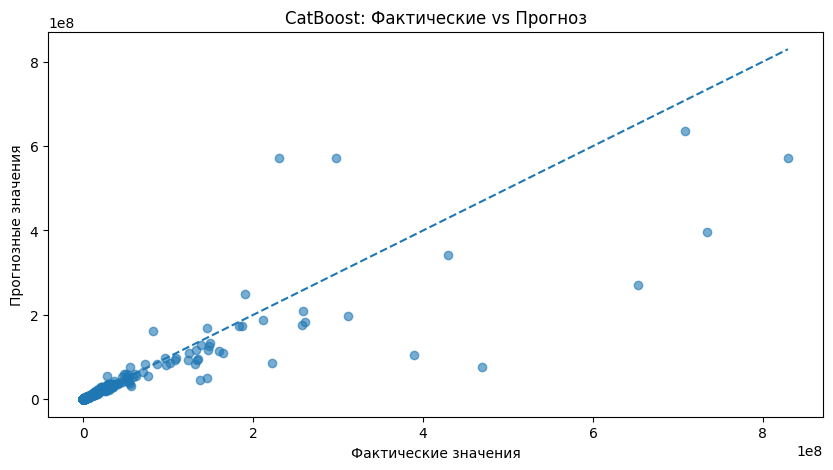

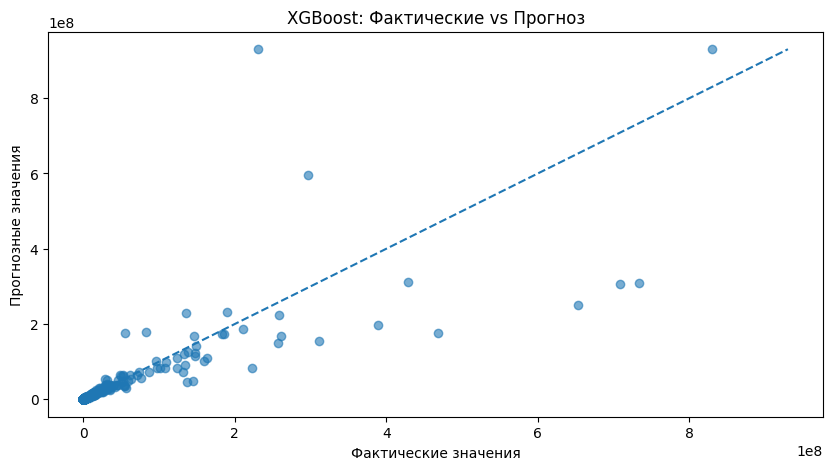

In [20]:
import matplotlib.pyplot as plt
import numpy as np

# Пример данных (предположим, что они у вас уже получены)
# y_test_orig = ...
# y_test_pred_cat = ...
# y_test_pred_xgb = ...

# Для наглядности используем min/max по фактическим и предсказанным значениям
min_val_cat = min(np.min(y_test_orig), np.min(y_test_pred_cat))
max_val_cat = max(np.max(y_test_orig), np.max(y_test_pred_cat))

min_val_xgb = min(np.min(y_test_orig), np.min(y_test_pred_xgb))
max_val_xgb = max(np.max(y_test_orig), np.max(y_test_pred_xgb))

# --- 1. Точечная диаграмма для CatBoost ---
plt.figure(figsize=(10, 5))
plt.scatter(y_test_orig, y_test_pred_cat, alpha=0.6)
plt.plot([min_val_cat, max_val_cat], [min_val_cat, max_val_cat], '--')  # линия Y=X
plt.title("CatBoost: Фактические vs Прогноз")
plt.xlabel("Фактические значения")
plt.ylabel("Прогнозные значения")
plt.show()

# --- 2. Точечная диаграмма для XGBoost ---
plt.figure(figsize=(10, 5))
plt.scatter(y_test_orig, y_test_pred_xgb, alpha=0.6)
plt.plot([min_val_xgb, max_val_xgb], [min_val_xgb, max_val_xgb], '--')  # линия Y=X
plt.title("XGBoost: Фактические vs Прогноз")
plt.xlabel("Фактические значения")
plt.ylabel("Прогнозные значения")
plt.show()

# Моделирование инвестиционной привлекательности

In [50]:
from sklearn.preprocessing import MinMaxScaler
import pandas as pd

# Группы признаков
groups = {
    "Демография и урбанизация": [
        'Численность населения', 'Степень урбанизации территории'
    ],
    "Транспортная доступность": [
        'Средняя доступность до федеральных транспортных магистралей',
        'Средняя доступность до центра региона',
        'Средняя доступность  автозаправочных станций',
        'Средняя доступность остановок железнодорожного транспорта',
        'Средняя доступность международных аэропортов',
        'Средняя доступность аэропортов местного значения',
    ],
    "Дорожная инфраструктура": [
        'Плотность улично-дорожной сети',
        'Протяженность дорог федерального значения',
        'Протяженность дорог регионального значения',
        'Протяженность дорог местного значения',
        'Количество остановок общественного транспорта',
        'Количество остановок железнодорожного транспорта',
        'Связанность',
        'Связанность населенных пунктов',
        'Связанность общественным транспортом'
    ],
    "Транспорт и автомобили": [
        'Количество автозаправочных станций',
        'Обеспеченность автозаправками',
        'Обеспеченность парковками',
        'Обеспеченность ЖД станциями',
        'Обеспеченность автосалонами / автосервисами'
    ],
    "Соц. инфраструктура": [
        'Обеспеченность детскими садами', 'Обеспеченность школами',
        'Обеспеченность центрами детского творчества',
        'Обеспеченность ФАП / амбулаториями', 'Обеспеченность аптеками',
        'Обеспеченность поликлиниками / центрами семейной медицины',
        'Обеспеченность участковыми больницами',
        'Обеспеченность городскими больницами (д/в)',
        'Обеспеченность коммерческими клиниками'
    ],
    "Коммерция": [
        'Обеспеченность продуктовыми магазинами',
        'Обеспеченность ТЦ / супермаркетами',
        'Обеспеченность зоомагазинами',
        'Обеспеченность ТРК / гипермаркетами',
        'Обеспеченность кафе / кофейнями',
        'Обеспеченность барами / ресторанами',
        'Обеспеченность пунктами доставки / почтовыми отделениями',
        'Обеспеченность парикмахерскими / салонами красоты',
        'Обеспеченность отделениями банков'
    ],
    "Общественные объекты": [
        'Обеспеченность комьюнити-центрами / домами культуры',
        'Обеспеченность культовыми объектами',
        'Обеспеченность участковыми пунктами полиции',
        'Обеспеченность опорными пунктами полиции',
        'Обеспеченность пожарными депо'
    ],
    "Рекреация и спорт": [
        'Обеспеченность детскими площадками',
        'Обеспеченность скверами / бульварами / лесопарками',
        'Обеспеченность парками',
        'Обеспеченность воркаутами / школьными спортзалами',
        'Обеспеченность спортзалами ОП / фитнес-центрами',
        'Обеспеченность ФОК / бассейнами'
    ]
}

# Копируем gdf, исключая geometry
df = gdf.drop(columns=['geometry']).copy()

# Результаты по группам
group_indicators = pd.DataFrame()
group_indicators['id'] = df['id']

# Нормализация и агрегация по группам
scaler = MinMaxScaler()

for group_name, columns in groups.items():
    # Убираем колонки, которых нет в gdf (на всякий случай)
    cols_present = [col for col in columns if col in df.columns]
    if not cols_present:
        continue

    # Масштабируем значения
    scaled = scaler.fit_transform(df[cols_present].fillna(0))
    
    # Считаем среднее значение по группе
    group_indicators[group_name] = scaled.mean(axis=1)

# Выбираем основные идентификаторы из оригинального GeoDataFrame
id_columns = ['id', 'territory_id', 'name', 'geometry']
identifiers = gdf[id_columns].copy()

# Объединяем с рассчитанными групповыми индикаторами по 'id'
gdf_grouped = identifiers.merge(group_indicators, on='id')
gdf_grouped["Площадь"] = gdf_grouped.geometry.area


import numpy as np
import pandas as pd
from scipy.stats import skew, kurtosis

# 1. Статистика по исходным признакам (исключая идентификаторы и geometry)
exclude_cols = ['id', 'territory_id', 'name', 'geometry']

# 2. Статистика по агрегированным группам (из предыдущего шага)
group_stats = group_indicators.drop(columns=['id']).copy()

# Функция для расширенной статистики
def extended_stats(df):
    stats = df.describe().T
    stats['median'] = df.median()
    stats['range'] = df.max() - df.min()
    stats['skewness'] = df.skew()
    stats['kurtosis'] = df.kurtosis()
    stats['missing_%'] = df.isna().mean() * 100
    return stats

# Получаем статистики

group_indicator_stats = extended_stats(group_stats)

print("\n📊 Статистика по группам индикаторов:")
display(group_indicator_stats)

territory_gdf = gpd.read_file('data/level_4_territories.geojson').to_crs(32636)

import json

# Убедимся, что parent — это словарь (если он закодирован как строка — преобразуем)
def extract_parent_name(x):
    if isinstance(x, str):
        try:
            x = json.loads(x)
        except json.JSONDecodeError:
            return None
    if isinstance(x, dict):
        return x.get("name")
    return None

# Создаём вспомогательный DataFrame
parent_df = territory_gdf[['name', 'parent']].copy()
parent_df['parent_name'] = parent_df['parent'].apply(extract_parent_name)

# Оставим только нужные колонки
parent_df = parent_df[['name', 'parent_name']]

# Мёржим с gdf_grouped
gdf_grouped = gdf_grouped.merge(parent_df, on='name', how='left')
gdf_grouped
# Шаг 1 — копируем оригинальный GeoDataFrame
gdf_grouped1 = gdf_grouped.copy()

# Шаг 2 — список колонок с нормализованными показателями
indicator_columns = [
    "Демография и урбанизация",
    "Транспортная доступность",
    "Дорожная инфраструктура",
    "Транспорт и автомобили",
    "Соц. инфраструктура",
    "Коммерция",
    "Общественные объекты",
    "Рекреация и спорт"
]

# Шаг 3 — расчёт "коэффициента качества" как среднего по нормализованным группам
gdf_grouped1["Индекс развития территории"] = gdf_grouped1[indicator_columns].mean(axis=1)

# # Шаг 4 — применим сглаживание (минимум 0.3)
# gdf_grouped1["Индекс развития территории_сглаженая"] = gdf_grouped1["Индекс развития территории"].apply(lambda x: max(0.5, x))

# Шаг 5 — пересчёт площади в сотки (100 м² = 1 сотка)
gdf_grouped1["Площадь (сотки)"] = gdf_grouped1["Площадь"] / 100

# Шаг 6 — добавим цену за сотку из словаря
districts_dict = {
    "Бокситогорский муниципальный район": 70,
    "Волосовский муниципальный район": 78,
    "Волховский муниципальный район": 101,
    "Всеволожский муниципальный район": 552,
    "Выборгский муниципальный район": 434,
    "Гатчинский муниципальный район": 272,
    "Кингисеппский муниципальный район": 94,
    "Киришский муниципальный район": 51,
    "Кировский муниципальный район": 227,
    "Лодейнопольский муниципальный район": 59,
    "Ломоносовский муниципальный район": 334,
    "Лужский муниципальный район": 66,
    "Подпорожский муниципальный район": 88,
    "Приозерский муниципальный район": 262,
    "Сланцевский муниципальный район": 21,
    "Тихвинский муниципальный район": 110,
    "Тосненский муниципальный район": 237,
    "Сосновоборский городской округ": 100
}

gdf_grouped1["Цена за сотку (тыс. руб.)"] = gdf_grouped1["parent_name"].map(districts_dict)

# Шаг 7 — расчёт итоговой стоимости (в тысячах рублей)
gdf_grouped1["Стоимость участка (тыс. руб.)"] = (
    gdf_grouped1["Площадь (сотки)"] *
    gdf_grouped1["Цена за сотку (тыс. руб.)"] *
    gdf_grouped1["Индекс развития территории"]
)




📊 Статистика по группам индикаторов:


,count,mean,std,min,25%,50%,75%,max,median,range,skewness,kurtosis,missing_%
Демография и урбанизация,34647.0,0.277371,0.152760,0.000919,0.154347,0.284186,0.371723,0.702327,0.284186,0.701408,0.276141,-0.190649,0.0
Транспортная доступность,34647.0,0.233359,0.125419,0.000000,0.144479,0.199024,0.315106,0.745230,0.199024,0.745230,0.931760,0.976706,0.0
Дорожная инфраструктура,34647.0,0.247096,0.093463,0.000000,0.173630,0.227892,0.312668,0.451188,0.227892,0.451188,0.315848,-0.835359,0.0
Транспорт и автомобили,34647.0,0.574470,0.158459,0.000000,0.480571,0.600000,0.693714,0.890857,0.600000,0.890857,-0.753474,0.712364,0.0
Соц. инфраструктура,34647.0,0.638115,0.153835,0.000000,0.527778,0.655556,0.753333,1.000000,0.655556,1.000000,-0.658019,0.746605,0.0
Коммерция,34647.0,0.668064,0.200590,0.000000,0.532411,0.721584,0.810449,0.977636,0.721584,0.977636,-0.888956,0.270374,0.0
Общественные объекты,34647.0,0.493212,0.151204,0.000000,0.398000,0.470000,0.604000,0.906000,0.470000,0.906000,0.173753,0.115305,0.0
Рекреация и спорт,34647.0,0.568643,0.218816,0.000000,0.411667,0.578333,0.716667,1.000000,0.578333,1.000000,-0.265039,-0.054428,0.0


In [ ]:

# 1. Нормализация площади и стоимости с помощью MinMaxScaler
scaler_area = MinMaxScaler()
scaler_price_per_sotka = MinMaxScaler()
scaler_total_cost = MinMaxScaler()

# Преобразуем столбцы в двумерный массив для MinMaxScaler
gdf_grouped1['Площадь_норм'] = scaler_area.fit_transform(gdf_grouped1[['Площадь (сотки)']])
gdf_grouped1['Цена_за_сотку_норм'] = scaler_price_per_sotka.fit_transform(gdf_grouped1[['Цена за сотку (тыс. руб.)']])
gdf_grouped1['Стоимость_участка_норм'] = scaler_total_cost.fit_transform(gdf_grouped1[['Стоимость участка (тыс. руб.)']])

# 2. Расчет инвестиционной привлекательности с учетом всех показателей и весов

# Коммерция: приоритет - транспорт, коммерческая активность, социальная инфраструктура
gdf_grouped1['Invest_Commerce'] = (
    0.25 * gdf_grouped1['Транспортная доступность'] +  # Высокая важность для клиентов и логистики
    0.20 * gdf_grouped1['Демография и урбанизация'] +                 # Наличие коммерческих объектов
    0.15 * gdf_grouped1['Соц. инфраструктура'] +       # Индекс развития территории для работников/посетителей
    0.10 * (1 - gdf_grouped1['Коммерция']) +  # Потенциальные клиенты
    0.10 * (1 - gdf_grouped1['Стоимость_участка_норм']) +  # Низкая стоимость - плюс
    0.05 * (1 - gdf_grouped1['Площадь_норм']) +        # Меньшая площадь предпочтительна
    0.05 * (1 - gdf_grouped1['Цена_за_сотку_норм']) +  # Доступная цена за сотку
    0.05 * gdf_grouped1['Рекреация и спорт'] +         # Дополнительный комфорт
    0.03 * gdf_grouped1['Общественные объекты'] +      # Второстепенно
    0.02 * gdf_grouped1['Дорожная инфраструктура'] +   # Менее важно
    0.05 * gdf_grouped1['Транспорт и автомобили']      # Удобство для транспорта
)

# Жилье: приоритет - демография, социальная инфраструктура, рекреация
gdf_grouped1['Invest_Residential'] = (
    0.20 * gdf_grouped1['Демография и урбанизация'] +  # Спрос на жилье
    0.20 * gdf_grouped1['Соц. инфраструктура'] +       # Школы, больницы и т.д.
    0.15 * gdf_grouped1['Рекреация и спорт'] +         # Качество жизни
    0.15 * gdf_grouped1['Транспортная доступность'] +  # Удобство для жителей
    0.10 * (1 - gdf_grouped1['Стоимость_участка_норм']) +  # Доступность для застройщиков
    0.05 * (1 - gdf_grouped1['Площадь_норм']) +        # Средняя площадь предпочтительна
    0.05 * (1 - gdf_grouped1['Цена_за_сотку_норм']) +  # Доступная цена за сотку
    0.05 * gdf_grouped1['Коммерция'] +                 # Наличие магазинов и услуг
    0.03 * gdf_grouped1['Общественные объекты'] +      # Второстепенно
    0.02 * gdf_grouped1['Дорожная инфраструктура'] +   # Менее важно
    0.05 * gdf_grouped1['Транспорт и автомобили']      # Удобство для жителей
)

# Промышленность: приоритет - дороги, транспорт, большая площадь
gdf_grouped1['Invest_Industry'] = (
    0.25 * gdf_grouped1['Дорожная инфраструктура'] +   # Логистика и подъездные пути
    0.20 * gdf_grouped1['Транспорт и автомобили'] +    # Доступность для грузов
    0.15 * gdf_grouped1['Площадь_норм'] +              # Большая площадь - плюс
    0.15 * (1 - gdf_grouped1['Цена_за_сотку_норм']) +  # Низкая цена за сотку
    0.10 * (1 - gdf_grouped1['Стоимость_участка_норм']) +  # Общая стоимость
    0.05 * gdf_grouped1['Транспортная доступность'] +  # Дополнительный фактор
    0.03 * gdf_grouped1['Демография и урбанизация'] +  # Менее важно
    0.03 * gdf_grouped1['Соц. инфраструктура'] +       # Второстепенно
    0.02 * gdf_grouped1['Коммерция'] +                 # Минимальная роль
    0.02 * gdf_grouped1['Общественные объекты'] +      # Минимальная роль
    0.05 * gdf_grouped1['Рекреация и спорт']           # Второстепенно
)

gdf_grouped1['Invest_Commerce'] += gdf_grouped1['Invest_Commerce'] * np.random.normal(0, 0.05, len(gdf_grouped1))
gdf_grouped1['Invest_Residential'] += gdf_grouped1['Invest_Residential'] * np.random.normal(0, 0.07, len(gdf_grouped1))
gdf_grouped1['Invest_Industry'] += gdf_grouped1['Invest_Industry'] * np.random.normal(0, 0.03, len(gdf_grouped1))


for col in ['Invest_Commerce', 'Invest_Residential', 'Invest_Industry']:
    gdf_grouped1[col] = gdf_grouped1[col].clip(0, 1)



📊 Статистика по группам индикаторов:


,count,mean,std,min,25%,50%,75%,max,median,range,skewness,kurtosis,missing_%
Демография и урбанизация,34647.0,0.277371,0.152760,0.000919,0.154347,0.284186,0.371723,0.702327,0.284186,0.701408,0.276141,-0.190649,0.0
Транспортная доступность,34647.0,0.233359,0.125419,0.000000,0.144479,0.199024,0.315106,0.745230,0.199024,0.745230,0.931760,0.976706,0.0
Дорожная инфраструктура,34647.0,0.247096,0.093463,0.000000,0.173630,0.227892,0.312668,0.451188,0.227892,0.451188,0.315848,-0.835359,0.0
Транспорт и автомобили,34647.0,0.574470,0.158459,0.000000,0.480571,0.600000,0.693714,0.890857,0.600000,0.890857,-0.753474,0.712364,0.0
Соц. инфраструктура,34647.0,0.638115,0.153835,0.000000,0.527778,0.655556,0.753333,1.000000,0.655556,1.000000,-0.658019,0.746605,0.0
Коммерция,34647.0,0.668064,0.200590,0.000000,0.532411,0.721584,0.810449,0.977636,0.721584,0.977636,-0.888956,0.270374,0.0
Общественные объекты,34647.0,0.493212,0.151204,0.000000,0.398000,0.470000,0.604000,0.906000,0.470000,0.906000,0.173753,0.115305,0.0
Рекреация и спорт,34647.0,0.568643,0.218816,0.000000,0.411667,0.578333,0.716667,1.000000,0.578333,1.000000,-0.265039,-0.054428,0.0


In [31]:
districts_dict = {
    "Бокситогорский муниципальный район": 70,
    "Волосовский муниципальный район": 78,
    "Волховский муниципальный район": 101,
    "Всеволожский муниципальный район": 552,
    "Выборгский муниципальный район": 434,
    "Гатчинский муниципальный район": 272,
    "Кингисеппский муниципальный район": 94,
    "Киришский муниципальный район": 51,
    "Кировский муниципальный район": 227,
    "Лодейнопольский муниципальный район": 59,
    "Ломоносовский муниципальный район": 334,
    "Лужский муниципальный район": 66,
    "Подпорожский муниципальный район": 88,
    "Приозерский муниципальный район": 262,
    "Сланцевский муниципальный район": 21,
    "Тихвинский муниципальный район": 110,
    "Тосненский муниципальный район": 237,
    "Сосновоборский городской округ": 100
}

/home/mvin/Urbanomy/.venv/lib/python3.10/site-packages/geopandas/geodataframe.py:1819: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)


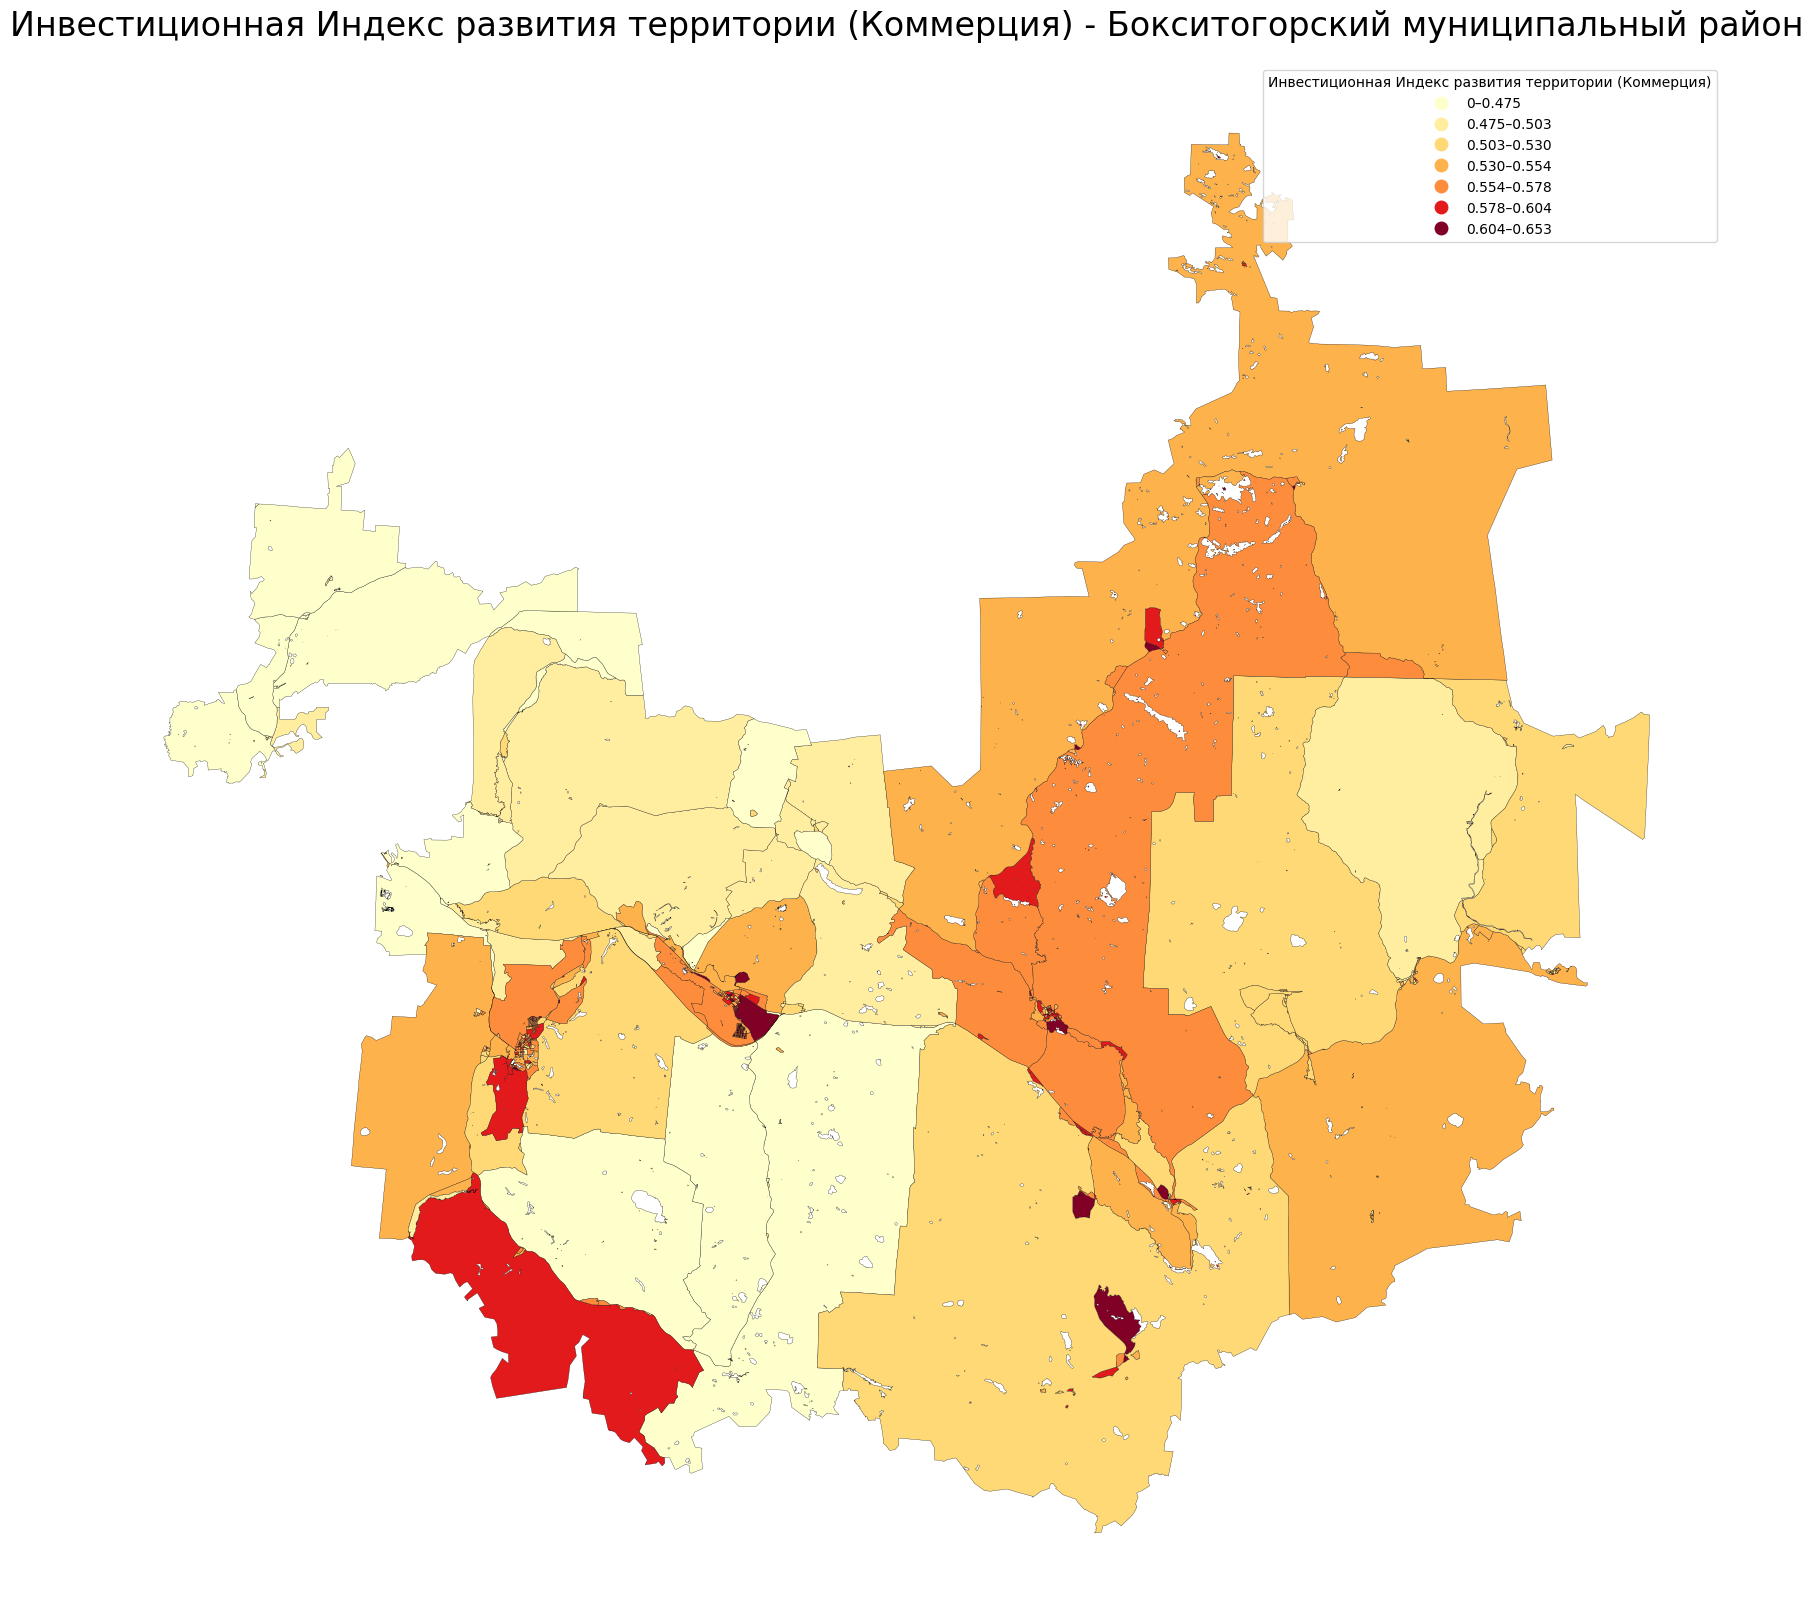

/home/mvin/Urbanomy/.venv/lib/python3.10/site-packages/geopandas/geodataframe.py:1819: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)


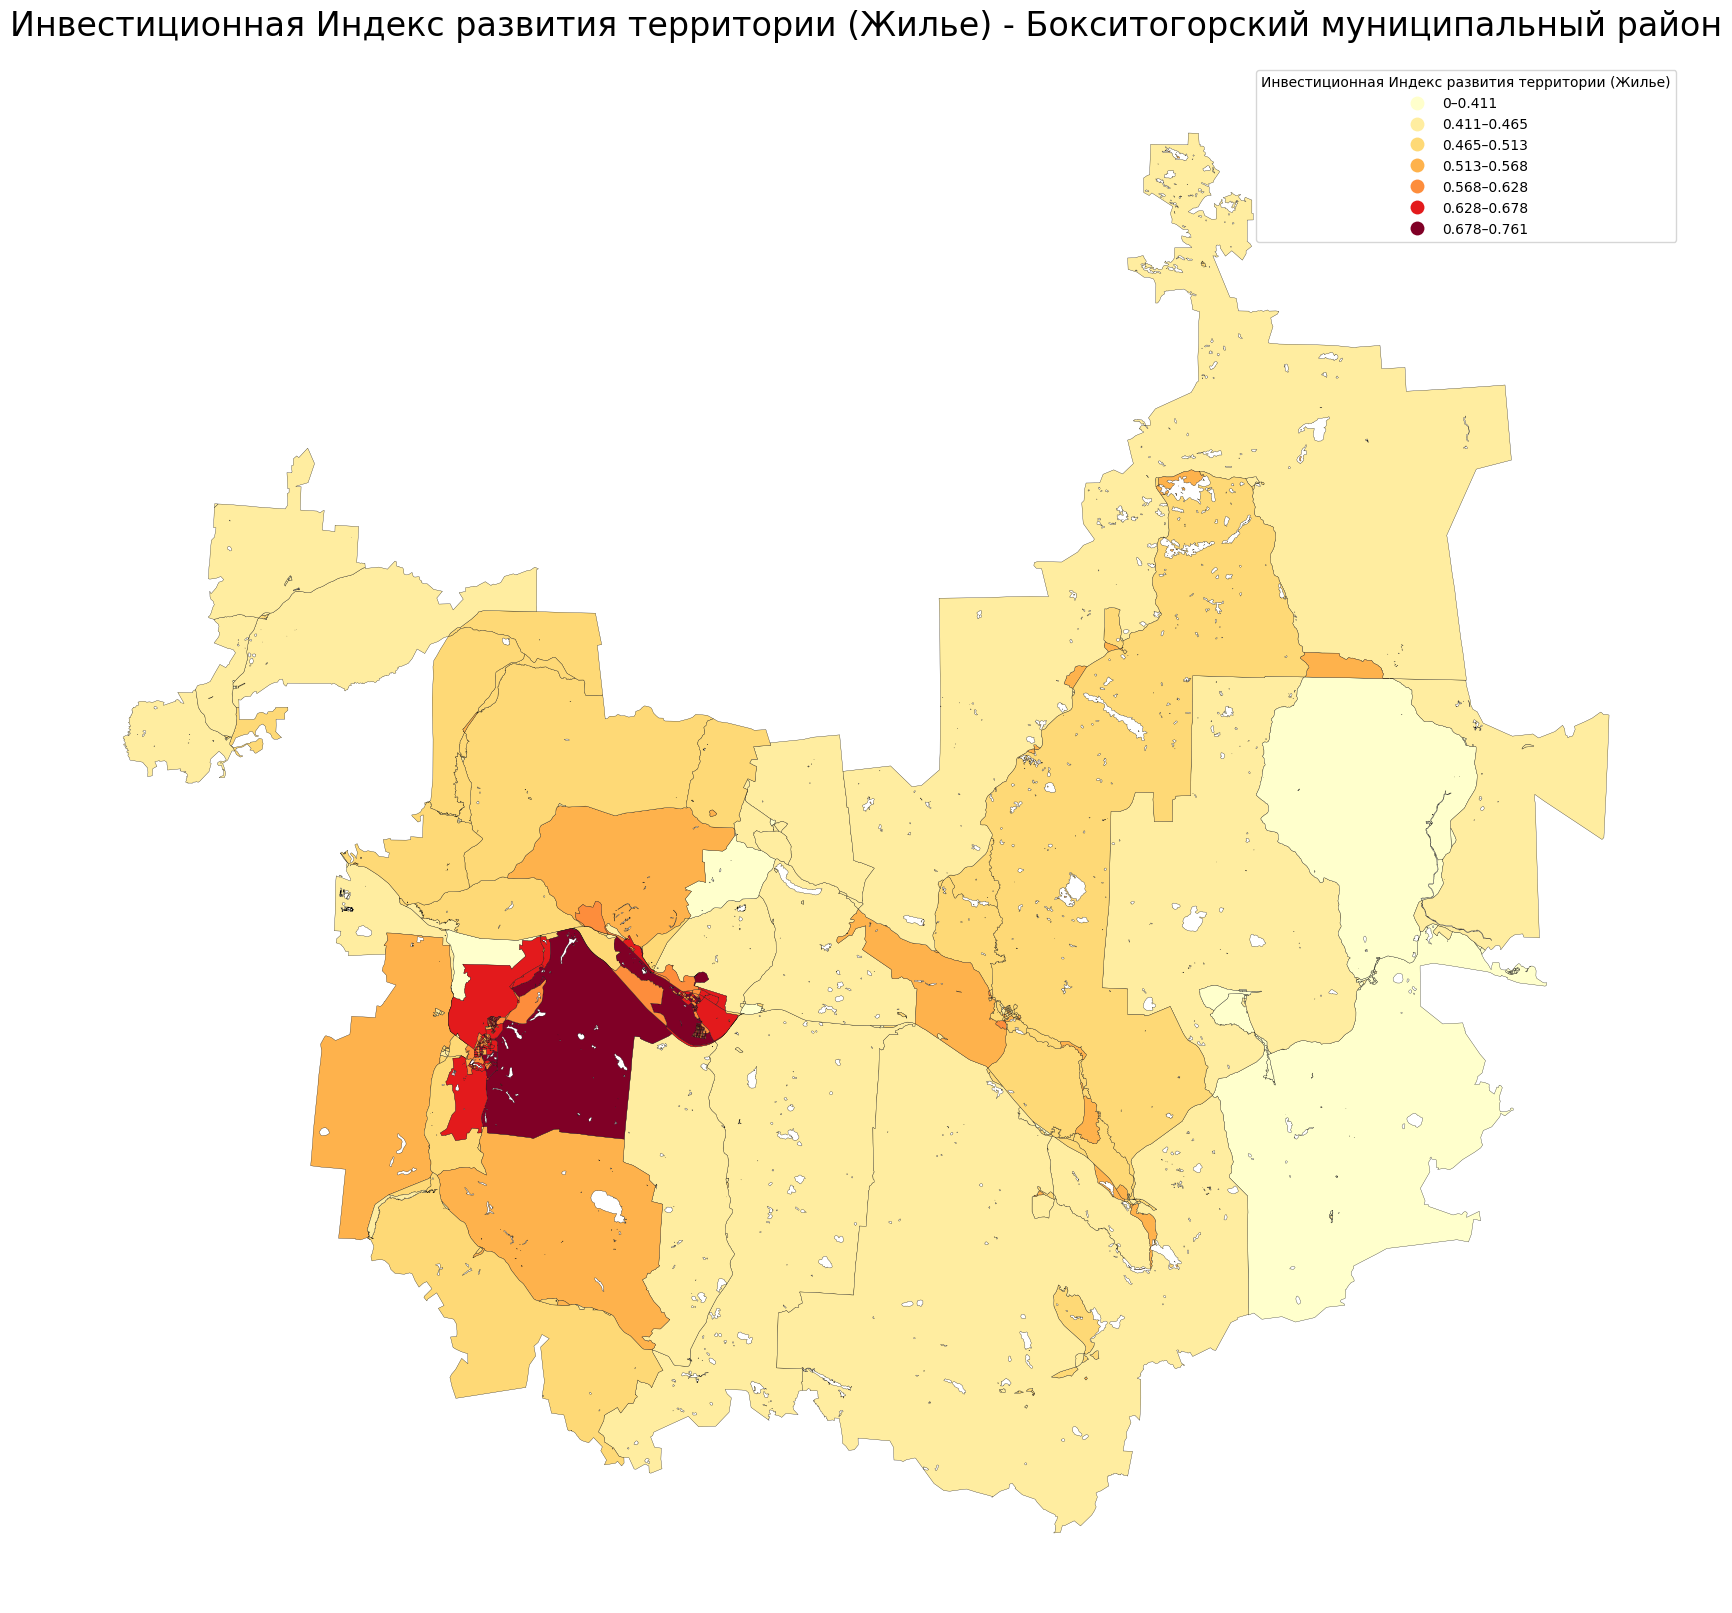

/home/mvin/Urbanomy/.venv/lib/python3.10/site-packages/geopandas/geodataframe.py:1819: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)


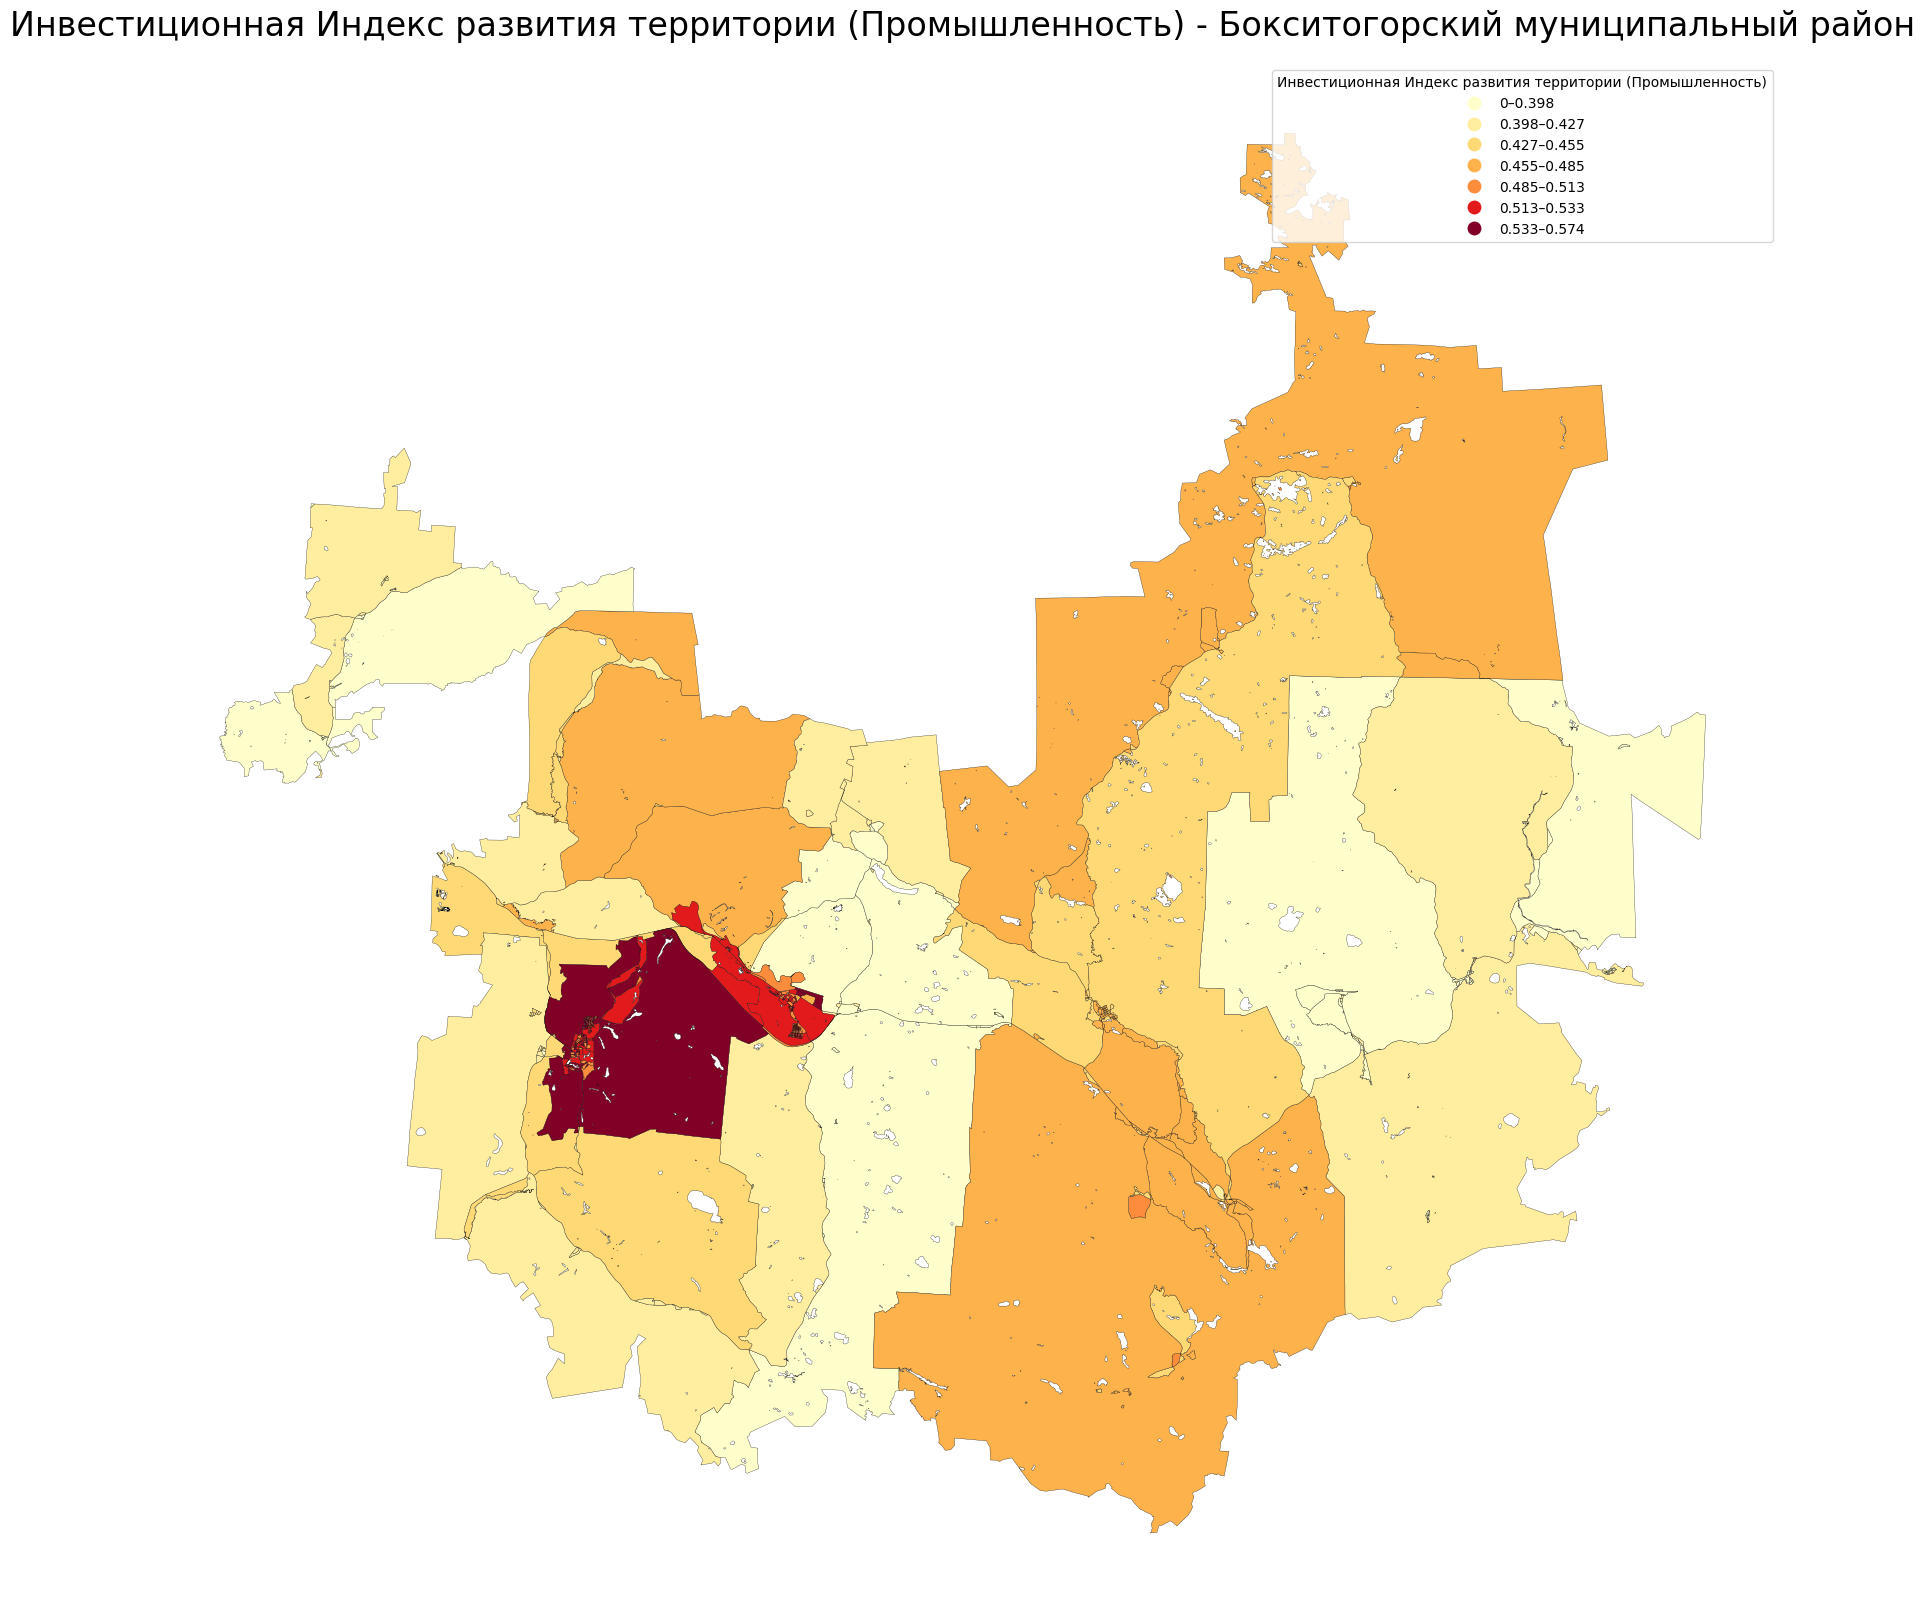

In [48]:
def plot_investment_map(gdf, column, title, parent_name, k=7):
    classifier = mapclassify.NaturalBreaks(gdf[column], k=k)
    bin_edges = classifier.bins
    bin_labels = [f"{bin_edges[i-1]:.3f}–{b:.3f}" if i > 0 else f"0–{b:.3f}" for i, b in enumerate(bin_edges)]
    
    gdf['Категория_стоимости'] = pd.cut(
        gdf[column],
        bins=[0] + list(bin_edges),
        labels=bin_labels,
        include_lowest=True,
        ordered=False
    )
    
    colors = ['#ffffcc', '#ffeda0', '#fed976', '#feb24c', '#fd8d3c', '#e31a1c', '#800026']
    cmap = mcolors.ListedColormap(colors)
    
    fig, ax = plt.subplots(1, 1, figsize=(40, 20))
    gdf.plot(
        column='Категория_стоимости',
        cmap=cmap,
        linewidth=0.2,
        edgecolor='black',
        legend=True,
        legend_kwds={'title': f"Инвестиционная Индекс развития территории ({title})"},
        ax=ax
    )
    plt.title(f'Инвестиционная Индекс развития территории ({title}) - {parent_name}', fontsize=24, pad=20)
    plt.axis('off')
    plt.show()

# Применение к трем показателям
filtered_gdf = gdf_grouped1[gdf_grouped1['parent_name'] == 'Бокситогорский муниципальный район']
parent_name = filtered_gdf['parent_name'].iloc[0] if not filtered_gdf.empty else "Не найдено"

plot_investment_map(filtered_gdf, 'Invest_Commerce', 'Коммерция', parent_name)
plot_investment_map(filtered_gdf, 'Invest_Residential', 'Жилье', parent_name)
plot_investment_map(filtered_gdf, 'Invest_Industry', 'Промышленность', parent_name)


=== Метрики для Invest_Commerce ===
                          CatBoost   XGBoost
Датасет          Метрика                    
Обучающие данные R2       0.858318  0.907791
                 MAPE     0.036399  0.028399
                 nRMSE    0.045551  0.036748
Тестовые данные  R2       0.812260  0.786165
                 MAPE     0.041563  0.044139
                 nRMSE    0.052278  0.055793

=== Метрики для Invest_Residential ===
                          CatBoost   XGBoost
Датасет          Метрика                    
Обучающие данные R2       0.823353  0.884059
                 MAPE     0.050330  0.039312
                 nRMSE    0.063286  0.051271
Тестовые данные  R2       0.768222  0.732974
                 MAPE     0.058037  0.062029
                 nRMSE    0.072814  0.078155

=== Метрики для Invest_Industry ===
                          CatBoost   XGBoost
Датасет          Метрика                    
Обучающие данные R2       0.954561  0.970170
                 MAPE     0.021


=== SHAP-анализ для Invest_Commerce ===
SHAP values (CatBoost) shape for Invest_Commerce: (26205, 12)


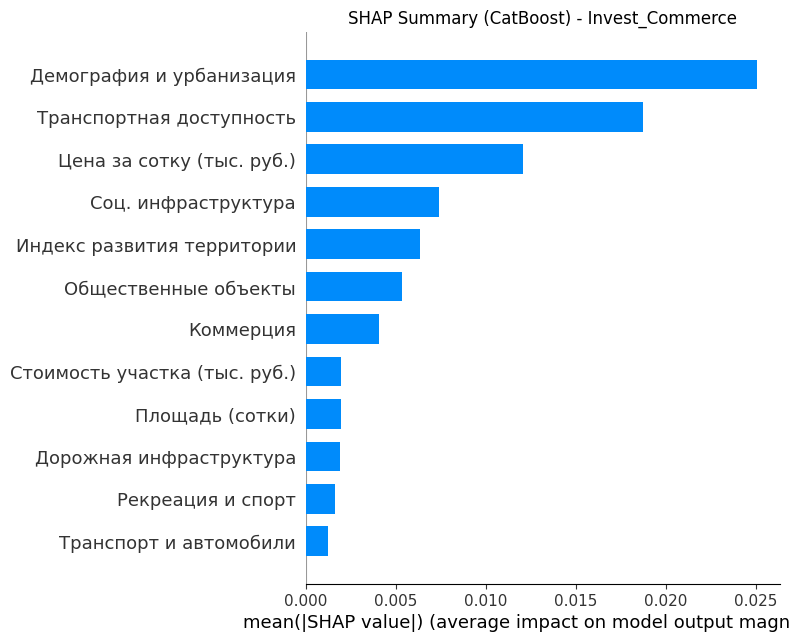

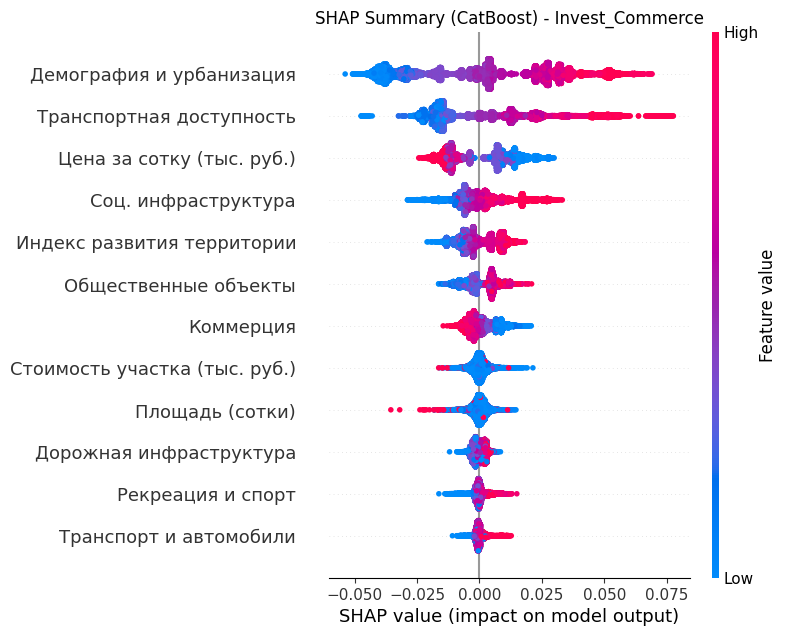

SHAP values (XGBoost) shape for Invest_Commerce: (26205, 12)


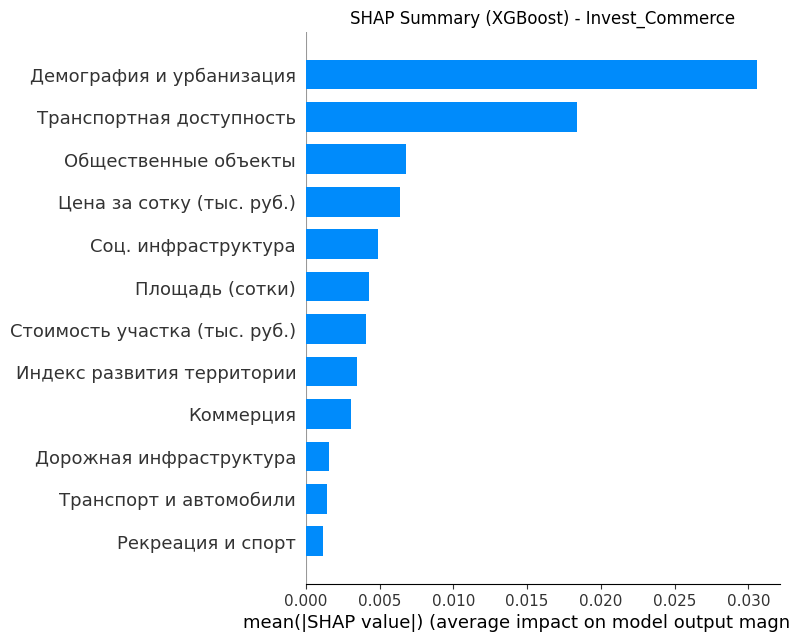

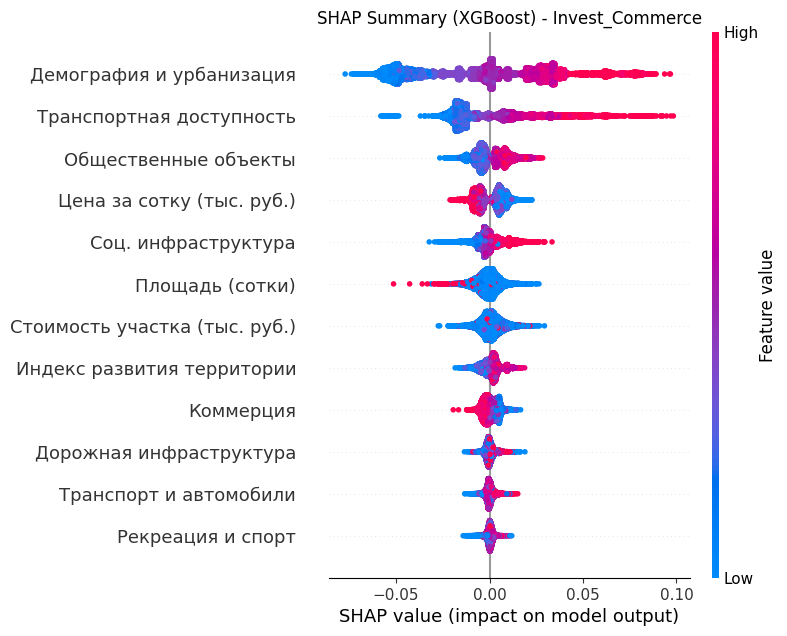


=== SHAP-анализ для Invest_Residential ===
SHAP values (CatBoost) shape for Invest_Residential: (26205, 12)


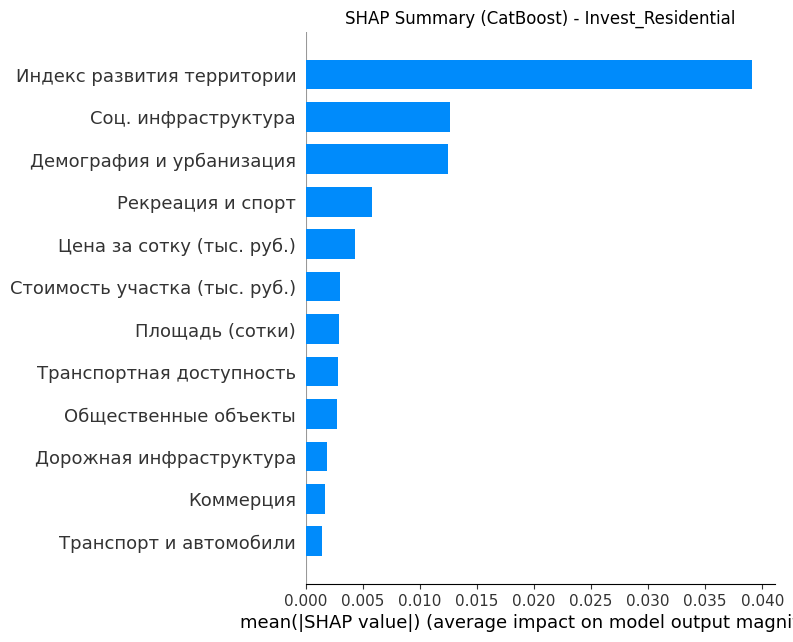

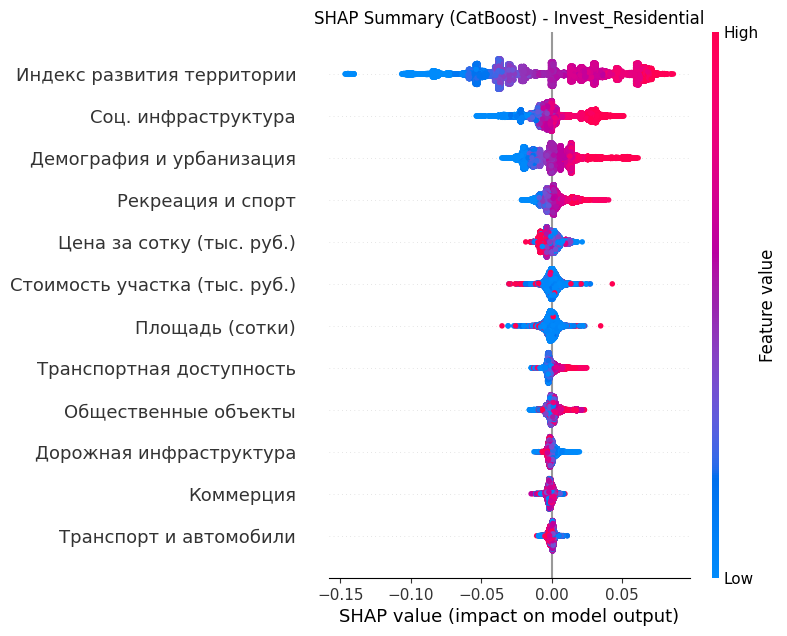

SHAP values (XGBoost) shape for Invest_Residential: (26205, 12)


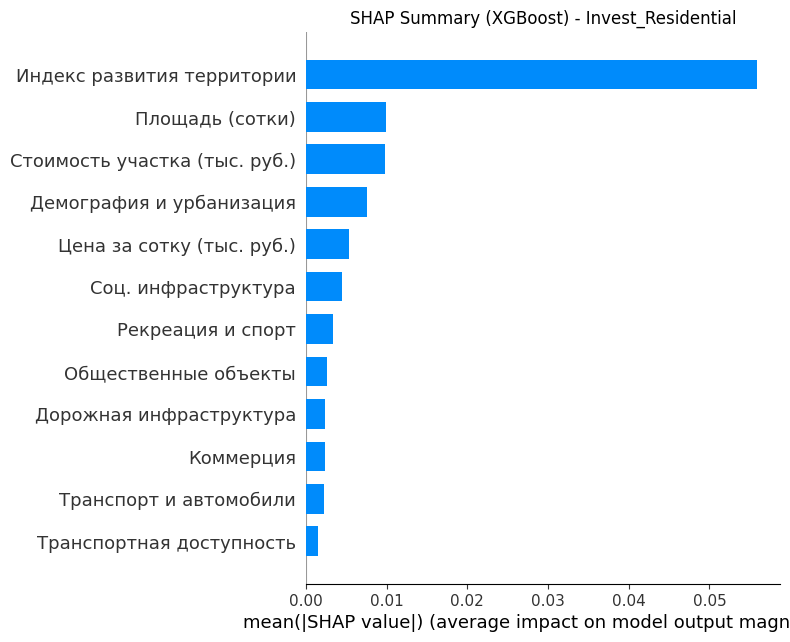

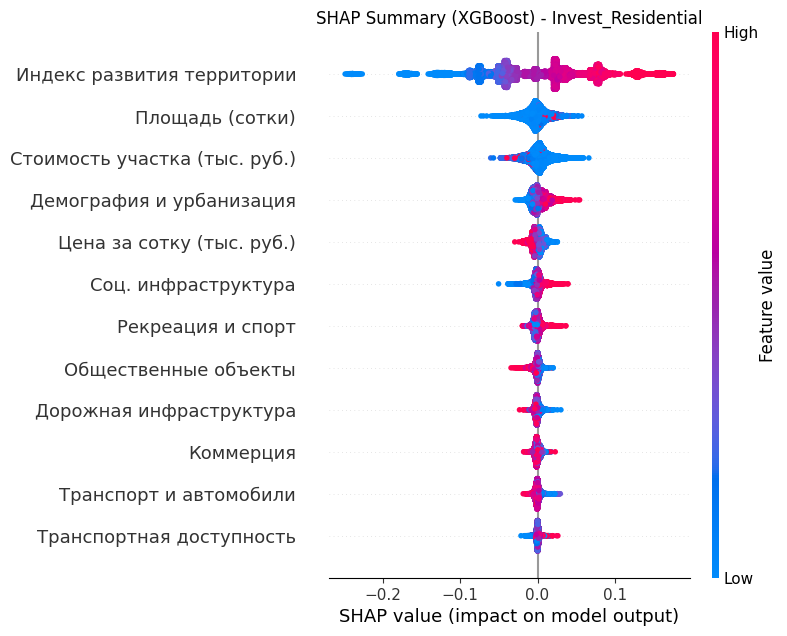


=== SHAP-анализ для Invest_Industry ===
SHAP values (CatBoost) shape for Invest_Industry: (26205, 12)


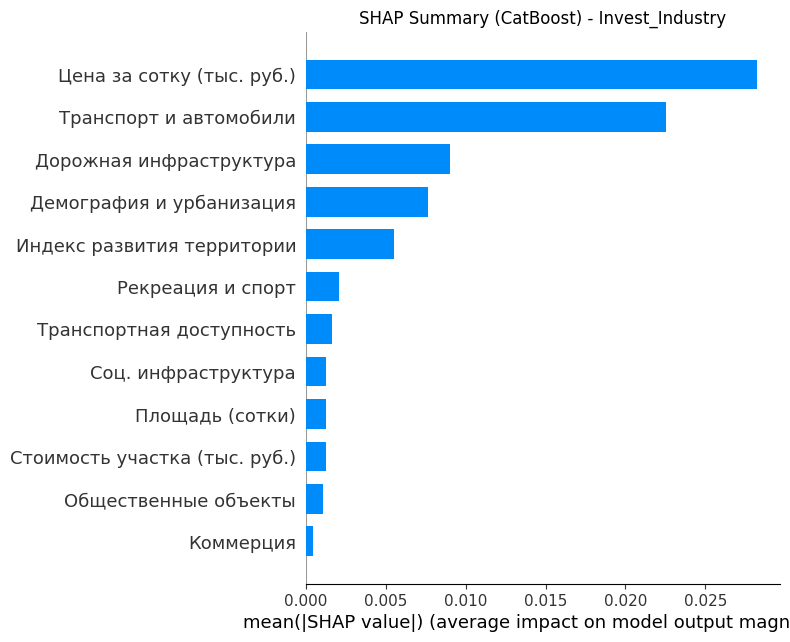

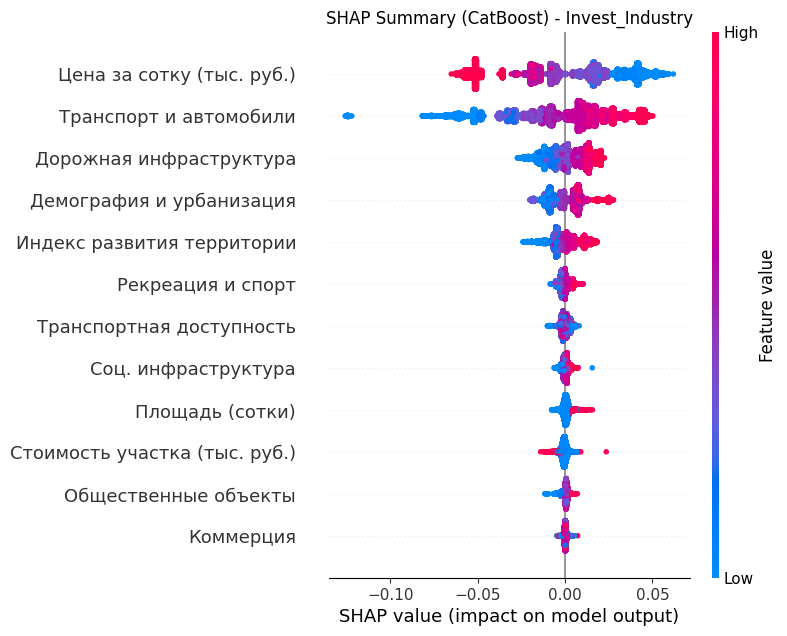

SHAP values (XGBoost) shape for Invest_Industry: (26205, 12)


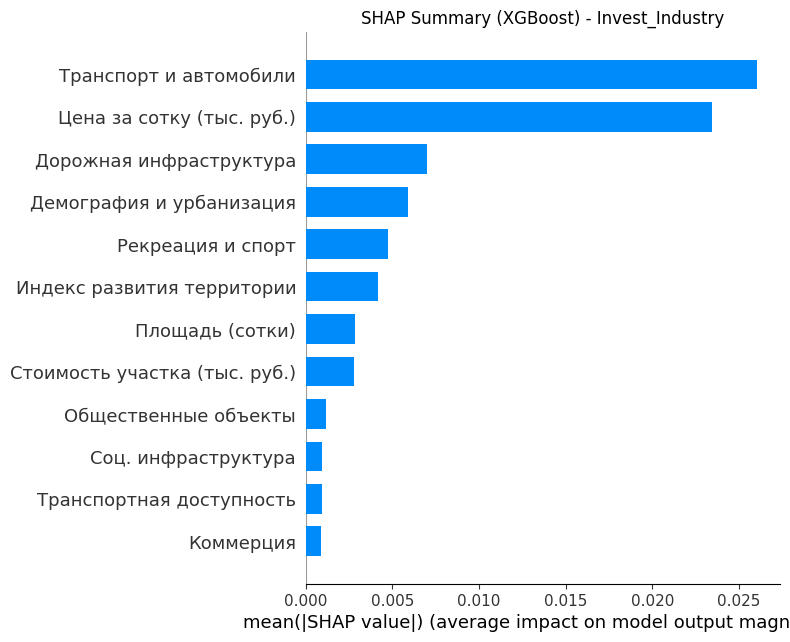

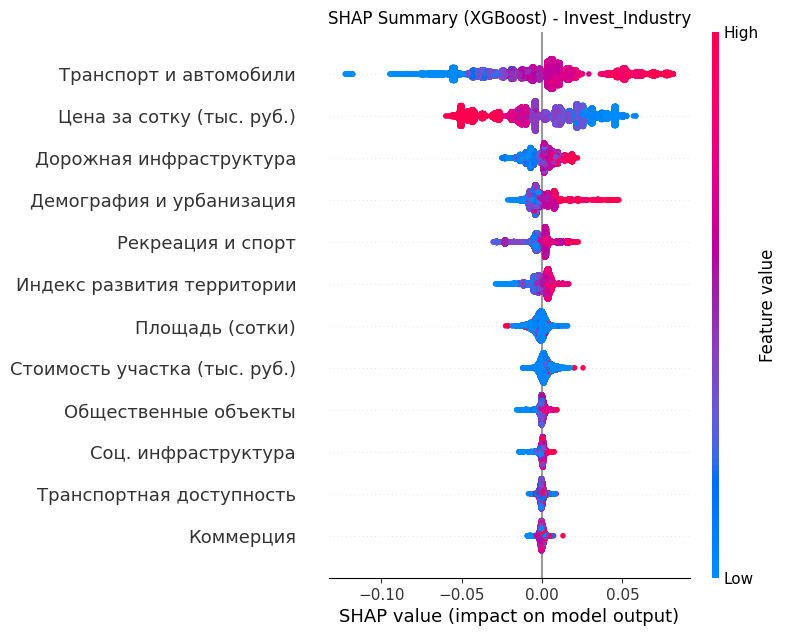

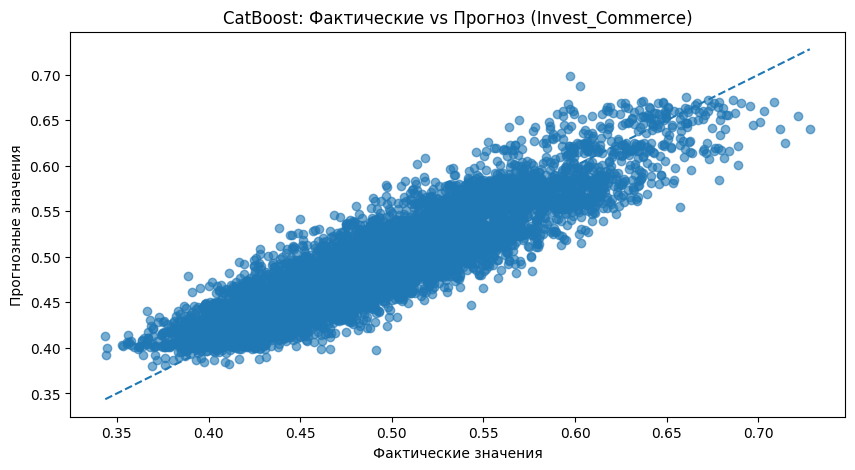

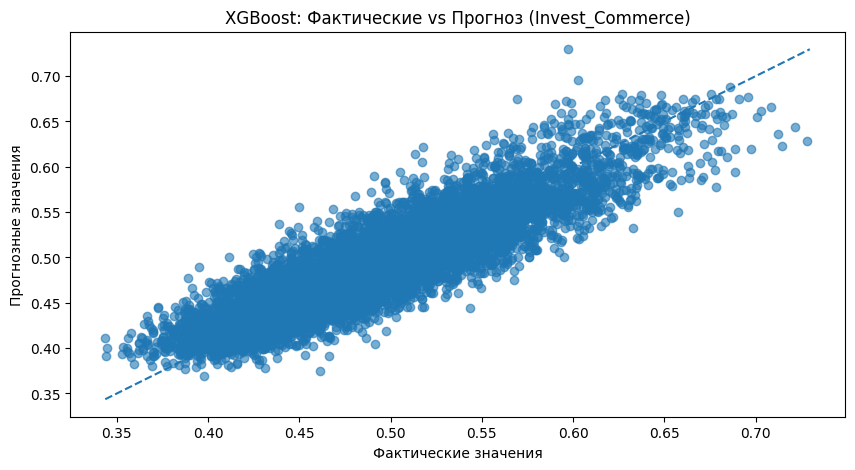

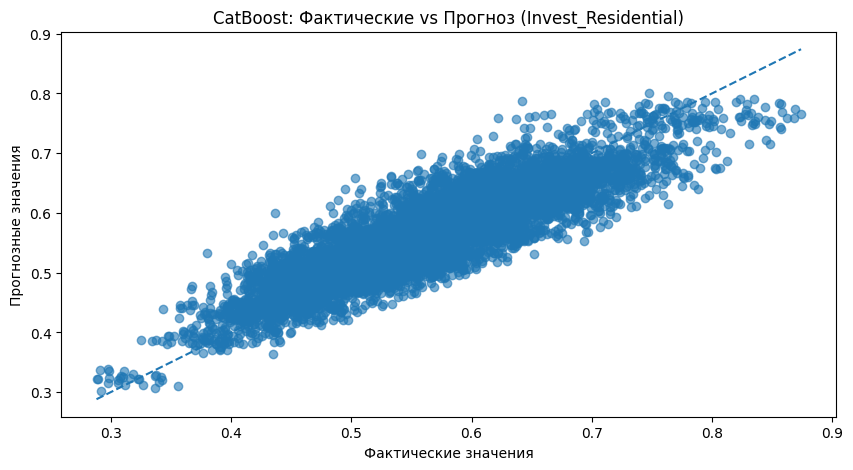

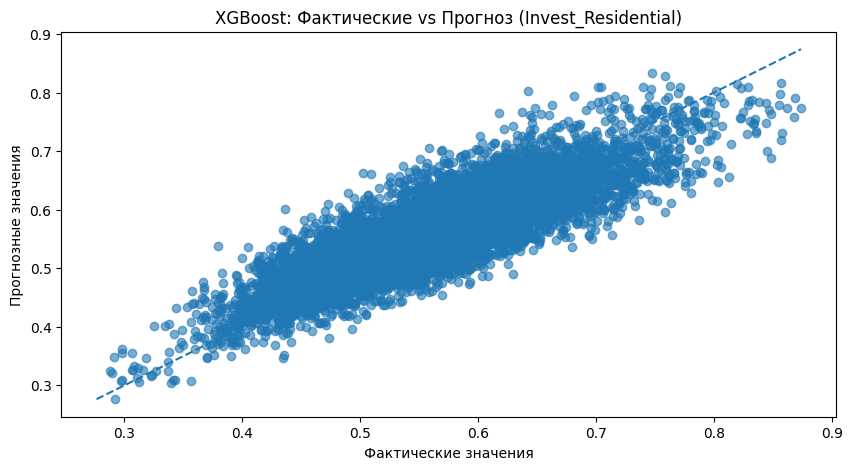

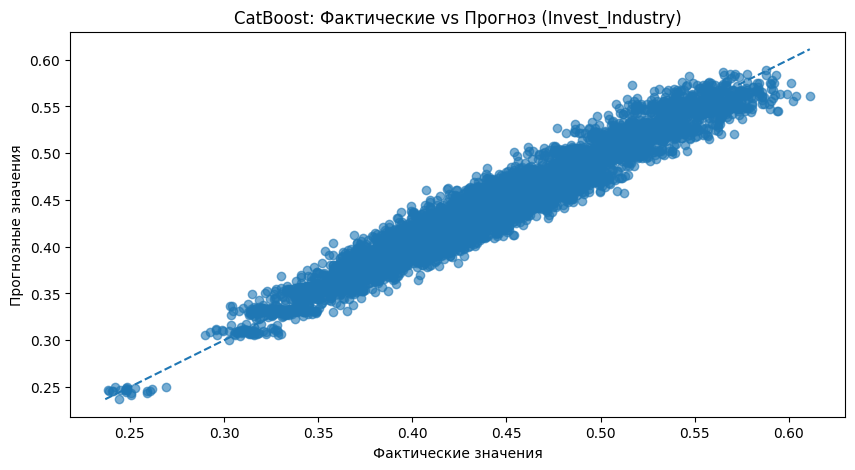

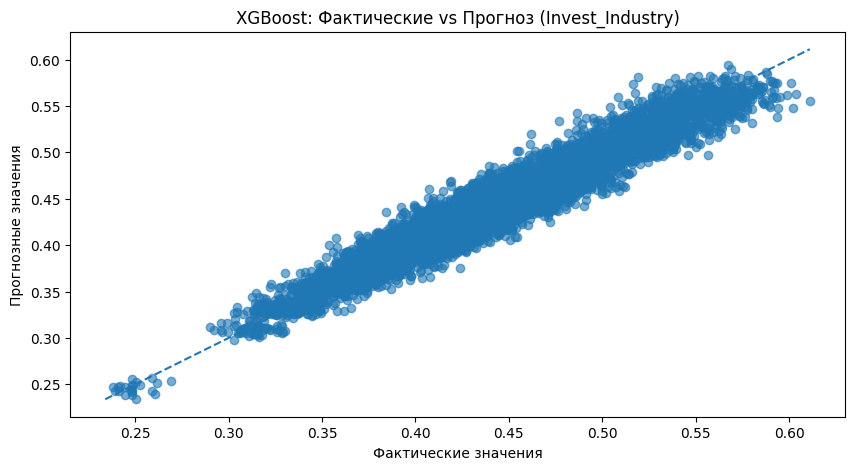

In [49]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error
from xgboost import XGBRegressor
from catboost import CatBoostRegressor
import shap
import matplotlib.pyplot as plt

# === 1. Функции для метрик ===
def mape(y_true, y_pred):
    """ MAPE = mean(|(y_true - y_pred) / y_true|). """
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    mask = y_true != 0  # Избегаем деления на ноль
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask]))

def nrmse(y_true, y_pred):
    """ nRMSE = RMSE / mean(y_true). """
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    return rmse / np.mean(y_true)

# === 2. Подготовка данных ===
feature_cols = [
    'Демография и урбанизация',
    'Транспортная доступность',
    'Дорожная инфраструктура',
    'Транспорт и автомобили',
    'Соц. инфраструктура',
    'Коммерция',
    'Общественные объекты',
    'Рекреация и спорт',
    'Площадь (сотки)',
    'Цена за сотку (тыс. руб.)',
    'Стоимость участка (тыс. руб.)',
    'Индекс развития территории'
]

# Целевые переменные
target_cols = ['Invest_Commerce', 'Invest_Residential', 'Invest_Industry']

# Предполагаем, что gdf_grouped1 уже содержит рассчитанные Invest_*
df_model = gdf_grouped1[feature_cols + target_cols].dropna()

X = df_model[feature_cols]
y = df_model[target_cols]

# Разделяем на train/test
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    random_state=42
)

# === 3. Обучение моделей для каждого типа землепользования ===
models = {'CatBoost': {}, 'XGBoost': {}}
predictions = {'CatBoost': {}, 'XGBoost': {}}
metrics = {'CatBoost': {}, 'XGBoost': {}}

for target in target_cols:
    # CatBoost
    cat_model = CatBoostRegressor(
        iterations=500,
        depth=6,
        learning_rate=0.26,
        subsample=1.0,
        rsm=1.0,
        random_seed=42,
        verbose=False
    )
    cat_model.fit(X_train, y_train[target])
    models['CatBoost'][target] = cat_model
    
    # Предсказания
    y_train_pred_cat = cat_model.predict(X_train)
    y_test_pred_cat = cat_model.predict(X_test)
    predictions['CatBoost'][target] = {'train': y_train_pred_cat, 'test': y_test_pred_cat}
    
    # Метрики
    metrics['CatBoost'][target] = {
        'R2_train': r2_score(y_train[target], y_train_pred_cat),
        'MAPE_train': mape(y_train[target], y_train_pred_cat),
        'nRMSE_train': nrmse(y_train[target], y_train_pred_cat),
        'R2_test': r2_score(y_test[target], y_test_pred_cat),
        'MAPE_test': mape(y_test[target], y_test_pred_cat),
        'nRMSE_test': nrmse(y_test[target], y_test_pred_cat)
    }

    # XGBoost
    xgb_model = XGBRegressor(
        n_estimators=500,
        learning_rate=0.26,
        max_depth=6,
        subsample=1.0,
        colsample_bytree=1.0,
        random_state=42
    )
    xgb_model.fit(X_train, y_train[target])
    models['XGBoost'][target] = xgb_model
    
    # Предсказания
    y_train_pred_xgb = xgb_model.predict(X_train)
    y_test_pred_xgb = xgb_model.predict(X_test)
    predictions['XGBoost'][target] = {'train': y_train_pred_xgb, 'test': y_test_pred_xgb}
    
    # Метрики
    metrics['XGBoost'][target] = {
        'R2_train': r2_score(y_train[target], y_train_pred_xgb),
        'MAPE_train': mape(y_train[target], y_train_pred_xgb),
        'nRMSE_train': nrmse(y_train[target], y_train_pred_xgb),
        'R2_test': r2_score(y_test[target], y_test_pred_xgb),
        'MAPE_test': mape(y_test[target], y_test_pred_xgb),
        'nRMSE_test': nrmse(y_test[target], y_test_pred_xgb)
    }

# === 4. Вывод метрик ===
for target in target_cols:
    print(f"\n=== Метрики для {target} ===")
    metrics_data = {
        "CatBoost": [
            metrics['CatBoost'][target]['R2_train'], metrics['CatBoost'][target]['MAPE_train'], metrics['CatBoost'][target]['nRMSE_train'],
            metrics['CatBoost'][target]['R2_test'], metrics['CatBoost'][target]['MAPE_test'], metrics['CatBoost'][target]['nRMSE_test']
        ],
        "XGBoost": [
            metrics['XGBoost'][target]['R2_train'], metrics['XGBoost'][target]['MAPE_train'], metrics['XGBoost'][target]['nRMSE_train'],
            metrics['XGBoost'][target]['R2_test'], metrics['XGBoost'][target]['MAPE_test'], metrics['XGBoost'][target]['nRMSE_test']
        ],
    }
    index = pd.MultiIndex.from_tuples([
        ('Обучающие данные', 'R2'),
        ('Обучающие данные', 'MAPE'),
        ('Обучающие данные', 'nRMSE'),
        ('Тестовые данные', 'R2'),
        ('Тестовые данные', 'MAPE'),
        ('Тестовые данные', 'nRMSE'),
    ], names=['Датасет', 'Метрика'])
    df_results = pd.DataFrame(metrics_data, index=index)
    print(df_results)

# === 5. SHAP-анализ ===
shap.initjs()

for target in target_cols:
    print(f"\n=== SHAP-анализ для {target} ===")
    
    # SHAP для CatBoost
    explainer_cat = shap.TreeExplainer(models['CatBoost'][target])
    shap_values_cat = explainer_cat.shap_values(X_train)
    print(f"SHAP values (CatBoost) shape for {target}:", np.array(shap_values_cat).shape)
    shap.summary_plot(shap_values_cat, X_train, plot_type="bar", show=False)
    plt.title(f"SHAP Summary (CatBoost) - {target}")
    plt.show()
    shap.summary_plot(shap_values_cat, X_train, show=False)
    plt.title(f"SHAP Summary (CatBoost) - {target}")
    plt.show()
    
    # SHAP для XGBoost
    explainer_xgb = shap.TreeExplainer(models['XGBoost'][target])
    shap_values_xgb = explainer_xgb.shap_values(X_train)
    print(f"SHAP values (XGBoost) shape for {target}:", np.array(shap_values_xgb).shape)
    shap.summary_plot(shap_values_xgb, X_train, plot_type="bar", show=False)
    plt.title(f"SHAP Summary (XGBoost) - {target}")
    plt.show()
    shap.summary_plot(shap_values_xgb, X_train, show=False)
    plt.title(f"SHAP Summary (XGBoost) - {target}")
    plt.show()

# === 6. Визуализация предсказаний ===
for target in target_cols:
    # CatBoost
    min_val_cat = min(np.min(y_test[target]), np.min(predictions['CatBoost'][target]['test']))
    max_val_cat = max(np.max(y_test[target]), np.max(predictions['CatBoost'][target]['test']))
    
    plt.figure(figsize=(10, 5))
    plt.scatter(y_test[target], predictions['CatBoost'][target]['test'], alpha=0.6)
    plt.plot([min_val_cat, max_val_cat], [min_val_cat, max_val_cat], '--')
    plt.title(f"CatBoost: Фактические vs Прогноз ({target})")
    plt.xlabel("Фактические значения")
    plt.ylabel("Прогнозные значения")
    plt.show()
    
    # XGBoost
    min_val_xgb = min(np.min(y_test[target]), np.min(predictions['XGBoost'][target]['test']))
    max_val_xgb = max(np.max(y_test[target]), np.max(predictions['XGBoost'][target]['test']))
    
    plt.figure(figsize=(10, 5))
    plt.scatter(y_test[target], predictions['XGBoost'][target]['test'], alpha=0.6)
    plt.plot([min_val_xgb, max_val_xgb], [min_val_xgb, max_val_xgb], '--')
    plt.title(f"XGBoost: Фактические vs Прогноз ({target})")
    plt.xlabel("Фактические значения")
    plt.ylabel("Прогнозные значения")
    plt.show()